# T23 -- Lung-Region Attention Module on ResNet50

Applies T18's Lung-Region Attention module (trained/validated on DenseNet121) to ResNet50 across
**seven arms (A0-A6)**: T18's six-arm ablation (A0 vanilla, A1 gate-only, A2 full, A3 multiply-gate,
A4 guidance-only, A5 CBAM) plus A6 (A2 + background-suppression loss). Design:
`T23_ResNet50_Lung_Attention_Implementation.md`; DenseNet121 reference:
`notebooks/T18_lung_region_attention.ipynb` (this notebook mirrors its S-section structure).

Everything architectural is imported unchanged from `src/`. T23-specific additions there:
`gradcam.get_taps(..., backbone_name="resnet50")` (ResNet50's pre-gate tap is `layer4[-1]`),
`comparison.run_significance_tests` (McNemar + Wilcoxon winner-selection gate), and
`datasets.preload_resized_cache` / `make_train_loader` (speed + per-run reproducibility, below).

## Running this across Kaggle sessions

The full ablation (7 arms x 15+40 epochs, two 5-config sweeps, evaluation, optional 3-seed repeat)
does not reliably fit in one 12-hour Kaggle session, so this notebook is **resumable**:

- Every unit of work (each arm, each sweep config, each arm's evaluation, the S7 checks) writes a
  `t23_done.json` marker when it finishes. Re-running the notebook skips finished units.
- A **budget guard** never *starts* a unit that won't finish before `SESSION_BUDGET_H` (S0), so a
  session always ends cleanly -- the notebook reaches its last cell and Kaggle saves the outputs.
- Results live in `/kaggle/working/T23_resnet50_lung_attention/` (the saved output).

**To continue after a session:** attach the previous session's results as an input -- either
**Add Input -> Your Work -> this notebook** (latest version's output), or the downloaded
`T23_resnet50_lung_attention` folder uploaded as a Kaggle Dataset -- then **Save Version** again. S0
finds the results by content and restores them. Repeat until the last cell prints `ALL DONE`.

**Speed:** training was CPU-bound (Kaggle's 4 vCPUs could decode/augment only ~half as fast as the
T4 trains). S2 now decodes + resizes every image once into RAM (~2.1 GB, a few minutes per session);
the tensors are **bit-identical** to reading from disk (asserted in S2), so this changes speed, not
results. Measured per-sample CPU cost: ~11.9 ms -> ~5.2 ms.

## S0 -- Setup

In [1]:
import time
SESSION_START = time.time()
# Kaggle kills sessions at 12h. Stop *starting* new work after this many hours, leaving margin for
# the cheap end-of-notebook cells and for Kaggle to save outputs.
SESSION_BUDGET_H = 11.0

import torch
print("PyTorch:", torch.__version__)
print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
assert torch.cuda.is_available(), "GPU is OFF -- Settings > Accelerator > GPU T4 before running the rest of this notebook."
device = torch.device("cuda")

PyTorch: 2.10.0+cu128
GPU available: True
GPU name: Tesla T4


In [2]:
import os, shutil
from pathlib import Path

ON_KAGGLE = Path("/kaggle/working").is_dir()


def find_dirs(root, predicate, max_depth=6,
              skip=("COVID-19_Radiography_Dataset", "images", "masks", "wandb", ".git", "__pycache__")):
    # Depth-limited directory search that never descends into the 21k-image dataset folders.
    found, stack = [], [(Path(root), 0)]
    while stack:
        d, depth = stack.pop()
        try:
            if predicate(d):
                found.append(d)
                continue
            if depth < max_depth:
                stack.extend((c, depth + 1) for c in d.iterdir() if c.is_dir() and c.name not in skip)
        except OSError:
            pass
    return sorted(found)


# The repo copy must contain this task's src/ changes. Checked by file content rather than by path,
# so a stale copy (an older dataset version, an old notebook output) is never silently used.
REQUIRED_CODE = {
    "src/datasets/covid_cxr.py": "def preload_resized_cache",
    "src/modules/comparison.py": "def run_significance_tests",
    "src/modules/gradcam.py": "_PRE_GATE_TAP",
    "configs/resnet50_lung_attention.yaml": "T23",
}

def repo_is_current(d):
    d = Path(d)
    return all((d / f).is_file() and marker in (d / f).read_text(encoding="utf-8") for f, marker in REQUIRED_CODE.items())


REPO_URL = "https://github.com/Ravindu-Pathirana/Chest-X-ray-Disease-Detection.git"
REPO_BRANCH = "main"  # fallback only, if no up-to-date repo dataset is attached

if ON_KAGGLE:
    # Kept outside /kaggle/working so the saved output contains results only, not a repo copy.
    REPO_ROOT = Path("/tmp/Chest-X-ray-Disease-Detection")
    if not repo_is_current(REPO_ROOT):
        _candidates = find_dirs("/kaggle/input", lambda d: (d / "src" / "modules" / "lung_attention.py").is_file())
        _current = [d for d in _candidates if repo_is_current(d)]
        print("Repo copies under /kaggle/input:", [str(c) for c in _candidates] or "none")
        shutil.rmtree(REPO_ROOT, ignore_errors=True)
        if _current:
            shutil.copytree(_current[0], REPO_ROOT, ignore=shutil.ignore_patterns(".git"))
            print("Using repo from dataset input:", _current[0])
        else:
            print("No up-to-date repo dataset attached -- falling back to git clone.")
            !git clone --branch $REPO_BRANCH --single-branch $REPO_URL $REPO_ROOT
    assert repo_is_current(REPO_ROOT), (
        "The repo copy is missing T23's src/ changes (" + ", ".join(REQUIRED_CODE) + "). "
        "Upload a new version of your repo Kaggle Dataset from your up-to-date local folder, "
        "then re-run from S0."
    )
    %pip install -q -r $REPO_ROOT/requirements.txt
    %pip install -q timm grad-cam
else:
    REPO_ROOT = next(p for p in (Path.cwd(), Path.cwd().parent) if (p / "src").is_dir())

print("REPO_ROOT:", REPO_ROOT)

Repo copies under /kaggle/input: ['/kaggle/input/datasets/sinethwickramaratna/chest-xray-disease-detection']
Using repo from dataset input: /kaggle/input/datasets/sinethwickramaratna/chest-xray-disease-detection
Note: you may need to restart the kernel to use updated packages.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 970.4 kB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Note: you may need to restart the kernel to use updated packages.
REPO_ROOT: /tmp/Chest-X-ray-Disease-Detection


In [3]:
import sys
sys.path.insert(0, str(REPO_ROOT))
from src.utils import load_config, merge_overrides, set_seed

### Restore previous sessions' results

If a previous session's results are attached as an input -- either the notebook's own output
(**Add Input -> Your Work**) or the `T23_resnet50_lung_attention` folder re-uploaded as a Kaggle
Dataset -- copy them into this session's output folder so finished units are skipped. They're found by
content (`session_timing.json` / the S7 done-marker), not by path, so the dataset's name and whether
you uploaded the folder or its contents don't matter. Attach the **latest** results: each session's
output already contains everything from the sessions before it. If several are attached, the one with
the most finished units is used.

In [4]:
T23_ROOT = (Path("/kaggle/working/T23_resnet50_lung_attention") if ON_KAGGLE
            else REPO_ROOT / "artifacts" / "T23_resnet50_lung_attention")
T23_ROOT.mkdir(parents=True, exist_ok=True)

if ON_KAGGLE:
    def _is_t23_output(d):
        # Matched by T23-only files, not by folder name: results re-uploaded as a Kaggle Dataset are mounted
        # under the dataset's slug. (T18's artifact folder also has runs/ + sweep/, so those alone don't qualify.)
        return (d / "session_timing.json").is_file() or (d / "smoke_test" / "t23_done.json").is_file()

    _prior = find_dirs("/kaggle/input", _is_t23_output)
    if _prior:
        _best = max(_prior, key=lambda d: len(list(d.rglob("t23_done.json"))))
        if len(_prior) > 1:
            print("Several previous outputs attached:", [str(p) for p in _prior], "-> restoring the most complete one.")
        shutil.copytree(_best, T23_ROOT, dirs_exist_ok=True)
        print(f"Restored {_best} -> {T23_ROOT} ({len(list(T23_ROOT.rglob('t23_done.json')))} finished units found).")
    else:
        print("No previous T23 output attached -- starting fresh (expected for the first session).")
print("T23_ROOT:", T23_ROOT)

No previous T23 output attached -- starting fresh (expected for the first session).
T23_ROOT: /kaggle/working/T23_resnet50_lung_attention


### W&B auth (hardened for headless "Save Version" runs)

Save Version runs have no stdin, so a missing W&B key raises `UsageError` and kills the run. This
tries Kaggle Secrets (`WANDB_API_KEY`; note Save Version has its own secrets toggle under
**Advanced Settings**) and otherwise falls back to `WANDB_MODE=offline`, which needs no
authentication. Offline runs still log locally (sync later with `wandb sync`); every number this
notebook uses downstream comes from its own JSON/CSV files, not W&B.

In [5]:
try:
    from kaggle_secrets import UserSecretsClient
    import wandb
    wandb.login(key=UserSecretsClient().get_secret("WANDB_API_KEY"))
    print("W&B login OK -- runs will sync live to your dashboard.")
except Exception as e:
    os.environ["WANDB_MODE"] = "offline"
    print(f"W&B secret/login unavailable ({type(e).__name__}: {e}) -- falling back to WANDB_MODE=offline.")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: sinethwickramaratna (sinethwickramaratna-university-of-moratuwa) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


W&B login OK -- runs will sync live to your dashboard.


## S1 -- Config + resume/budget helpers

Loads `configs/resnet50_lung_attention.yaml` (arm A2's config, copied from `baseline.yaml`; other
arms via `merge_overrides()`), then defines the done-marker and session-budget helpers every
expensive section uses.

`PIPELINE_VERSION` is stamped into every done-marker. A unit only counts as finished if its marker
carries the current version, so results from an older data pipeline (e.g. a run from before the RAM
cache / per-run loader change) are retrained rather than mixed into the same ablation -- an A0
trained differently from A1-A6 would confound every delta.

In [6]:
import json
import pandas as pd

cfg = load_config(REPO_ROOT / "configs" / "resnet50_lung_attention.yaml")
print("Loaded config for experiment:", cfg["experiment"]["name"])
print(json.dumps(cfg, indent=2))

Loaded config for experiment: T23_resnet50_lung_attention
{
  "experiment": {
    "name": "T23_resnet50_lung_attention",
    "seed": 42
  },
  "model": {
    "name": "resnet50",
    "pretrained": true,
    "num_classes": 4,
    "drop_rate": 0.0
  },
  "module": {
    "name": "lung_region_attention",
    "attention": "lung",
    "use_attention": true,
    "in_channels": 2048,
    "reduction": 8,
    "gate_mode": "residual",
    "target_mode": "soft",
    "lambda_att": 1.0,
    "lambda_bg": 0.0
  },
  "dataset": {
    "name": "covid19_radiography",
    "version": "v1",
    "image_size": 224,
    "split_version": "v1",
    "use_masks": true
  },
  "training": {
    "phase1_epochs": 15,
    "phase1_lr": 0.001,
    "phase2_epochs": 40,
    "phase2_lr": 5e-05,
    "unfreeze_blocks": 1,
    "batch_size": 32,
    "optimizer": "adamw",
    "weight_decay": 0.0001,
    "patience": 5
  },
  "scheduler": {
    "name": "cosine"
  },
  "augmentation": {
    "version": "joint_v1"
  },
  "tracking": {


In [7]:
from contextlib import contextmanager

PIPELINE_VERSION = "t23-ramcache-freshloader-v1"  # bump if data pipeline/protocol changes -> forces retraining
DONE_MARKER = "t23_done.json"
EVAL_MARKER = "t23_eval_done.json"


def _marker_ok(path):
    try:
        return json.loads(Path(path).read_text()).get("pipeline") == PIPELINE_VERSION
    except (OSError, json.JSONDecodeError):
        return False

def is_done(d):
    return _marker_ok(Path(d) / DONE_MARKER)

def read_done(d):
    return json.loads((Path(d) / DONE_MARKER).read_text())

def mark_done(d, **info):
    Path(d).mkdir(parents=True, exist_ok=True)
    (Path(d) / DONE_MARKER).write_text(json.dumps({"pipeline": PIPELINE_VERSION, **info}, indent=2, default=str))


# --- Session budget: durations of finished units are persisted, so later sessions plan with real numbers ---
TIMING_PATH = T23_ROOT / "session_timing.json"
_timing = json.loads(TIMING_PATH.read_text()) if TIMING_PATH.exists() else {}
DEFAULT_EST_H = {"arm": 1.5, "sweep_cfg": 0.35, "eval_arm": 0.25}  # conservative until measured

def hours_left():
    return SESSION_BUDGET_H - (time.time() - SESSION_START) / 3600

def can_start(kind, label=""):
    seen = _timing.get(kind, [])
    est_h = max(seen) / 3600 * 1.15 if seen else DEFAULT_EST_H[kind]
    if hours_left() > est_h:
        return True
    print(f"[budget] Not starting {kind} {label}: {hours_left():.2f}h left of {SESSION_BUDGET_H}h, needs ~{est_h:.2f}h. "
          f"It runs next session.")
    return False

@contextmanager
def timed(kind):
    t0 = time.time()
    yield
    _timing.setdefault(kind, []).append(time.time() - t0)
    TIMING_PATH.write_text(json.dumps(_timing, indent=2))
    print(f"[timing] {kind} took {(time.time() - t0) / 60:.1f} min; {hours_left():.2f}h left in this session.")

## S2 -- Data layer -- RAM-cached, mask-paired dataset + verification

Same pipeline and same committed split manifest as T18 (`artifacts/splits/split_manifest_v1.csv`), so
ResNet50 and DenseNet121 are compared on identical images. `cache_in_ram=True` decodes + resizes every
image/mask once (JointTransform's own first step); the verification cell below asserts the cached
tensors are bit-identical to the on-disk path, in both eval and train (augmented) mode.

Every training run gets a **fresh** train loader seeded with that run's seed (`fresh_train_loader`).
A shared loader's generator carries state between runs, so arm N's data order would depend on how
many epochs ran before it in the same session -- and would silently change once runs are split
across sessions.

In [8]:
import numpy as np
import torch.nn as nn
from src.datasets import (
    build_dataloaders, compute_class_weights, make_train_loader,
    CachedCXRWithMaskDataset, CXRWithMaskDataset, JointTransform,
)

_KAGGLE_DATA_DIR = "/kaggle/input/datasets/tawsifurrahman/covid19-radiography-database/COVID-19_Radiography_Dataset"
if ON_KAGGLE:
    DATA_DIR = _KAGGLE_DATA_DIR if Path(_KAGGLE_DATA_DIR).is_dir() else str(find_dirs(
        "/kaggle/input", lambda d: d.name == "COVID-19_Radiography_Dataset", skip=("images", "masks", ".git"))[0])
else:
    DATA_DIR = str(next(p for p in (
        REPO_ROOT.parent.parent / "Baseline Model" / "data" / "COVID-19_Radiography_Dataset",
        Path("/Volumes/My Disk 2/My Projects/Chest Disease Detection/COVID-19_Radiography_Dataset"),
    ) if p.is_dir()))
print("Using DATA_DIR:", DATA_DIR)

SPLIT_MANIFEST = REPO_ROOT / "artifacts" / "splits" / "split_manifest_v1.csv"
assert SPLIT_MANIFEST.exists(), f"{SPLIT_MANIFEST} not found -- it must be committed (T18 generated it)."

# Workers share the RAM cache copy-on-write under fork (Linux/Kaggle). Under Windows' spawn each
# worker would pickle its own 2 GB copy, so run single-process locally.
NUM_WORKERS = 4 if ON_KAGGLE else 0
SEED = cfg["experiment"]["seed"]

_t0 = time.time()
train_loader, val_loader, test_loader, class_names, train_targets, datasets = build_dataloaders(
    DATA_DIR,
    img_size=cfg["dataset"]["image_size"],
    batch_size=cfg["training"]["batch_size"],
    seed=SEED,
    num_workers=NUM_WORKERS,
    split_manifest_path=SPLIT_MANIFEST,
    cache_in_ram=True,
    persistent_workers=True,
)
CACHE_IMAGES, CACHE_MASKS = datasets["train"].images, datasets["train"].masks
print(f"Cached {len(CACHE_IMAGES)} image/mask pairs in RAM in {time.time() - _t0:.0f}s "
      f"({(CACHE_IMAGES.nbytes + CACHE_MASKS.nbytes) / 1e9:.2f} GB)")
print(f"Classes ({len(class_names)}): {class_names}")
print(f"Train/Val/Test sizes: {len(datasets['train'])}/{len(datasets['val'])}/{len(datasets['test'])}")

class_weights = compute_class_weights(train_targets, num_classes=len(class_names)).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
print("Class weights:", class_weights.cpu().tolist())


def fresh_train_loader(seed):
    return make_train_loader(datasets["train"], cfg["training"]["batch_size"], seed,
                             num_workers=NUM_WORKERS, persistent_workers=True)

def cached_subset(base_indices, train):
    return CachedCXRWithMaskDataset(datasets["train"].base_dataset, np.asarray(base_indices),
                                    JointTransform(img_size=224, train=train), CACHE_IMAGES, CACHE_MASKS)

Using DATA_DIR: /kaggle/input/datasets/tawsifurrahman/covid19-radiography-database/COVID-19_Radiography_Dataset
Cached 21165 image/mask pairs in RAM in 134s (2.12 GB)
Classes (4): ['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']
Train/Val/Test sizes: 14815/3175/3175
Class weights: [1.4633543491363525, 0.8801687359809875, 0.5191687941551208, 3.9317941665649414]


In [9]:
# --- S2 verification: split sizes, batch contract, and RAM cache == disk (bit-exact) ---
import random

CLASSES = ["COVID", "Lung_Opacity", "Normal", "Viral Pneumonia"]
assert (len(datasets["train"]), len(datasets["val"]), len(datasets["test"])) == (14815, 3175, 3175)
assert class_names == CLASSES, class_names
print("[1] split sizes + class order OK")

imgs, labels, masks = next(iter(train_loader))
assert imgs.shape[1:] == (3, 224, 224), imgs.shape
assert masks.shape[1:] == (1, 224, 224), masks.shape
assert set(torch.unique(masks).tolist()) <= {0.0, 1.0}
print("[2] batch shapes OK:", imgs.shape, masks.shape)
del train_loader  # training uses fresh_train_loader(seed) per run; release this loader's workers

_probe = np.asarray(datasets["train"].indices[:12])
for _train_mode in (False, True):
    _disk = CXRWithMaskDataset(datasets["train"].base_dataset, _probe, JointTransform(img_size=224, train=_train_mode))
    _ram = cached_subset(_probe, train=_train_mode)
    for k in range(len(_probe)):
        random.seed(k); torch.manual_seed(k); a = _disk[k]
        random.seed(k); torch.manual_seed(k); b = _ram[k]
        assert a[1] == b[1] and torch.equal(a[0], b[0]) and torch.equal(a[2], b[2]), (
            f"RAM cache differs from disk at probe sample {k} (train={_train_mode})")
print("[3] RAM cache is bit-identical to the on-disk pipeline (eval + augmented train mode)")

[1] split sizes + class order OK
[2] batch shapes OK: torch.Size([32, 3, 224, 224]) torch.Size([32, 1, 224, 224])
[3] RAM cache is bit-identical to the on-disk pipeline (eval + augmented train mode)


### Alignment eyeball check

Confirm masks still line up after augmentation.

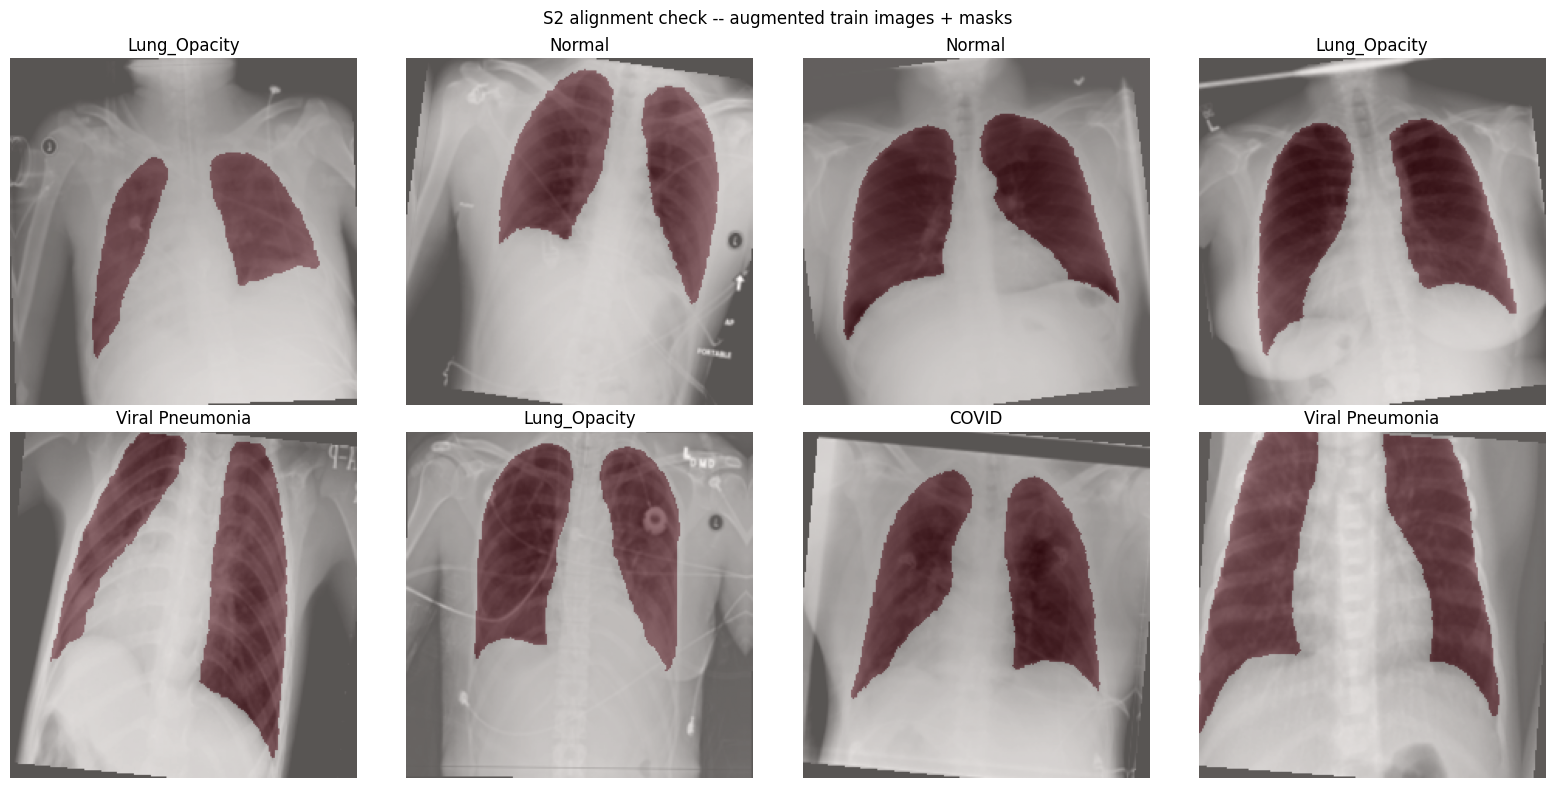

In [10]:
import matplotlib.pyplot as plt
from src.datasets import IMAGENET_MEAN, IMAGENET_STD

mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
std = torch.tensor(IMAGENET_STD).view(3, 1, 1)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for k, ax in enumerate(axes.flat):
    show = (imgs[k] * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
    ax.imshow(show)
    ax.imshow(masks[k, 0].numpy(), cmap="Reds", alpha=0.35)
    ax.set_title(class_names[labels[k]])
    ax.axis("off")
plt.suptitle("S2 alignment check -- augmented train images + masks")
plt.tight_layout()
plt.show()

## S3 -- The Lung-Region Attention module (reused, not reimplemented)

Canonical code: `src/modules/lung_attention.py`, validated by T18's unit tests and Kaggle run.

In [11]:
from src.modules import (
    build_model, freeze_backbone, unfreeze_final_blocks, print_trainable_parameters,
    LungRegionAttention, LogitsOnly,
)
import timm

## S4 -- Assemble the model on ResNet50 + parity check against vanilla

`gate_mode="none"` must give bit-identical logits to plain timm ResNet50; parameter counts are
checked against the analytic numbers (verified locally against timm before this notebook shipped).
CPU-only, seconds.

In [12]:
torch.manual_seed(0)
_wrapped = build_model(num_classes=4, use_attention=True, gate_mode="none", pretrained=False, backbone_name="resnet50")
_plain = timm.create_model("resnet50", pretrained=False, num_classes=4)
_plain.load_state_dict(_wrapped.backbone.state_dict())
_plain.eval(); _wrapped.eval()

_x = torch.randn(2, 3, 224, 224)
with torch.no_grad():
    _plain_logits = _plain(_x)
    _wrapped_logits, _, _ = _wrapped(_x)
torch.testing.assert_close(_wrapped_logits, _plain_logits, rtol=0, atol=0)
print("PARITY CHECK PASSED: gate_mode='none' logits are bit-identical to plain timm ResNet50")

_a0 = build_model(num_classes=4, use_attention=False, pretrained=False, backbone_name="resnet50")
_vanilla_params = sum(p.numel() for p in _plain.parameters())
_a0_params = sum(p.numel() for p in _a0.parameters())
print(f"A0 params: {_a0_params:,} | vanilla timm ResNet50 params: {_vanilla_params:,}")
assert _a0_params == _vanilla_params == 23_516_228, (_a0_params, _vanilla_params)

PARITY CHECK PASSED: gate_mode='none' logits are bit-identical to plain timm ResNet50
A0 params: 23,516,228 | vanilla timm ResNet50 params: 23,516,228


In [13]:
_attn = LungRegionAttention(2048, reduction=8, gate_mode="residual")
_attn_params = sum(p.numel() for p in _attn.parameters())
print(f"Attention module params: {_attn_params:,} ({100.0 * _attn_params / _vanilla_params:.4f}% of vanilla ResNet50)")
assert _attn_params == 524_801, _attn_params

model = build_model(num_classes=4, use_attention=True, gate_mode="residual", pretrained=False, backbone_name="resnet50")
freeze_backbone(model)
print_trainable_parameters(model, "phase1 ")
assert sum(p.numel() for p in model.parameters() if p.requires_grad) == 532_997  # classifier 8,196 + attn 524,801

unfreeze_final_blocks(model, num_blocks=1)
print_trainable_parameters(model, "phase2 ")
assert sum(p.numel() for p in model.parameters() if p.requires_grad) == 15_497_733  # + layer4 14,964,736
del model, _wrapped, _plain, _a0
print("\nS4 verification passed.")

Attention module params: 524,801 (2.2317% of vanilla ResNet50)
phase1 Trainable: 532,997 / 24,041,029 (2.22%)
phase2 Trainable: 15,497,733 / 24,041,029 (64.46%)

S4 verification passed.


## S5 -- Metrics (reused) + ResNet50's Grad-CAM taps

The pre-gate tap is architecture-specific (DenseNet: `features.norm5`; ResNet50: `layer4[-1]`), so
every call passes `backbone_name="resnet50"`.

In [14]:
from src.modules import (
    ilar, attention_iou, attention_dice, attention_entropy, background_attention,
    energy_inside_lung, cam_for, get_taps,
)

_mask = torch.zeros(1, 1, 224, 224); _mask[:, :, 64:160, 48:176] = 1.0
_frac = _mask.mean().item()
assert abs(ilar(_mask.clone(), _mask).item() - 1.0) < 1e-4
assert abs(ilar(torch.ones(1, 1, 7, 7), _mask).item() - _frac) < 0.02
assert ilar(1.0 - _mask, _mask).item() < 1e-4
assert abs(attention_iou(_mask.clone(), _mask).item() - 1.0) < 1e-4
assert abs(attention_dice(_mask.clone(), _mask).item() - 1.0) < 1e-4
assert abs(attention_entropy(torch.full((1, 1, 7, 7), 0.5)).item() - 0.69315) < 1e-4
assert background_attention(_mask.clone(), _mask).item() < 1e-4
assert abs(energy_inside_lung(_mask.clone(), _mask).item() - 1.0) < 1e-4
print("All metric self-checks passed.")

# Arm A0 has no gate, so EIL at the post-gate and pre-gate taps must agree.
_demo_model = build_model(num_classes=4, use_attention=False, pretrained=False, backbone_name="resnet50")
_demo_images = torch.randn(2, 3, 224, 224)
_tap_post, _tap_pre = get_taps(_demo_model, backbone_name="resnet50")
_cam_post, _ = cam_for(_demo_model, _demo_images, _tap_post, torch.device("cpu"))
_cam_pre, _ = cam_for(_demo_model, _demo_images, _tap_pre, torch.device("cpu"))
_eil_post = energy_inside_lung(_cam_post, _mask.repeat(2, 1, 1, 1))
_eil_pre = energy_inside_lung(_cam_pre, _mask.repeat(2, 1, 1, 1))
assert torch.allclose(_eil_post, _eil_pre, atol=1e-3), (_eil_post, _eil_pre)
del _demo_model
print("Grad-CAM harness self-check passed on ResNet50's pre-gate tap (backbone.layer4[-1]).")

All metric self-checks passed.
Grad-CAM harness self-check passed on ResNet50's pre-gate tap (backbone.layer4[-1]).


## S6 -- Training loop (reused) + resumable run helpers

`run_full_arm` / `train_phase` / `evaluate` are unchanged from T18. The two helpers below wrap them
with: skip-if-done, the session budget guard, a fresh per-run train loader, and a done-marker
recording the arm's settings (used later to label the comparison table without reloading checkpoints).

In [15]:
import gc
from src.modules import run_full_arm, train_phase, evaluate, build_optimizer, build_scheduler, best_history_row
from src.utils import initialize_wandb, finish_run, generate_run_name

RUNS_ROOT = T23_ROOT / "runs"
SWEEP_ROOT = T23_ROOT / "sweep"
FIG_DIR = T23_ROOT / "figures"
for _d in (RUNS_ROOT, SWEEP_ROOT, FIG_DIR):
    _d.mkdir(parents=True, exist_ok=True)


def train_arm_if_needed(arm_name, arm_cfg, out_dir):
    # Returns the arm's phase-2 test results, or None if it didn't fit in this session's budget.
    out_dir = Path(out_dir)
    if is_done(out_dir):
        print(f"[resume] {arm_name}: already trained -- loading saved test results.")
        return json.loads((out_dir / "phase2_finetune_test_results.json").read_text())
    if not can_start("arm", arm_name):
        return None
    (out_dir / EVAL_MARKER).unlink(missing_ok=True)  # any earlier evaluation belongs to a different checkpoint
    m = arm_cfg["module"]
    seed = arm_cfg["experiment"]["seed"]
    loader = fresh_train_loader(seed)
    try:
        with timed("arm"):
            results = run_full_arm(
                arm_name, arm_cfg, loader, val_loader, test_loader, class_names, criterion,
                device, out_dir, backbone_name="resnet50", wandb_enabled=True,
            )
    finally:
        del loader
        gc.collect(); torch.cuda.empty_cache()
    mark_done(out_dir, arm=arm_name, seed=seed, use_attention=m["use_attention"], attention=m.get("attention", "lung"),
              gate_mode=m.get("gate_mode", "residual"), lambda_att=m["lambda_att"], lambda_bg=m.get("lambda_bg", 0.0))
    return results


TUNE_PHASE1_EPOCHS = 4
TUNE_PHASE2_EPOCHS = 6
TUNE_PATIENCE = 3
TOLERANCE = 0.005  # 0.5 percentage points of val macro-F1, absolute


def run_sweep_config_if_needed(name, lambda_att, lambda_bg):
    # Short-schedule, validation-only sweep point. Returns its result row, or None if deferred by the budget.
    cfg_dir = SWEEP_ROOT / name
    if is_done(cfg_dir):
        print(f"[resume] sweep {name}: already done.")
        return read_done(cfg_dir)["row"]
    if not can_start("sweep_cfg", name):
        return None
    set_seed(SEED)
    cfg_dir.mkdir(parents=True, exist_ok=True)
    loader = fresh_train_loader(SEED)
    t = cfg["training"]
    try:
        initialize_wandb(cfg, run_name=generate_run_name("resnet50", f"T23-sweep-{name}", SEED))
        with timed("sweep_cfg"):
            sweep_model = build_model(
                num_classes=cfg["model"]["num_classes"], use_attention=True, gate_mode=cfg["module"]["gate_mode"],
                pretrained=cfg["model"]["pretrained"], backbone_name="resnet50", drop_rate=cfg["model"]["drop_rate"],
            ).to(device)
            freeze_backbone(sweep_model)
            opt1 = build_optimizer(sweep_model, t["optimizer"], t["phase1_lr"], t["weight_decay"])
            sweep_model = train_phase(
                sweep_model, loader, val_loader, criterion, opt1,
                build_scheduler(opt1, cfg["scheduler"]["name"], TUNE_PHASE1_EPOCHS), device,
                epochs=TUNE_PHASE1_EPOCHS, patience=TUNE_PATIENCE, phase_name="phase1_frozen",
                output_dir=cfg_dir, lambda_att=lambda_att, lambda_bg=lambda_bg, wandb_enabled=True,
            )
            # No evaluate() call -- test data stays out of hyperparameter selection entirely.
            unfreeze_final_blocks(sweep_model, t["unfreeze_blocks"])
            opt2 = build_optimizer(sweep_model, t["optimizer"], t["phase2_lr"], t["weight_decay"])
            sweep_model = train_phase(
                sweep_model, loader, val_loader, criterion, opt2,
                build_scheduler(opt2, cfg["scheduler"]["name"], TUNE_PHASE2_EPOCHS), device,
                epochs=TUNE_PHASE2_EPOCHS, patience=TUNE_PATIENCE, phase_name="phase2_finetune",
                output_dir=cfg_dir, lambda_att=lambda_att, lambda_bg=lambda_bg, wandb_enabled=True,
            )
        best = best_history_row(cfg_dir / "phase2_finetune_history.json")
        row = {
            "name": name, "lambda_att": lambda_att, "lambda_bg": lambda_bg,
            "phase1_lr": t["phase1_lr"], "phase2_lr": t["phase2_lr"], "weight_decay": t["weight_decay"],
            "optimizer": t["optimizer"], "scheduler": cfg["scheduler"]["name"],
            "best_epoch": best["epoch"], "best_val_loss": best["val_loss"], "val_acc_at_best_loss": best["val_acc"],
            "val_macro_f1_at_best": best["val_f1"], "val_ilar_at_best": best["val_ilar"],
        }
    finally:
        finish_run()
        del loader
        gc.collect(); torch.cuda.empty_cache()
    mark_done(cfg_dir, row=row)
    return row


def select_largest_within_tolerance(df, lam_col, reference_name):
    # Pre-registered rule: largest lambda whose val macro-F1 is within TOLERANCE of the lambda=0
    # reference; ties broken by higher val ILAR.
    ref_f1 = df.loc[df["name"] == reference_name, "val_macro_f1_at_best"].iloc[0]
    cands = df[df["val_macro_f1_at_best"] >= ref_f1 - TOLERANCE]
    if cands.empty:
        raise RuntimeError(f"No {lam_col} within 0.5pp of {reference_name} -- extend the grid downward (e.g. 0.05, 0.03).")
    top = cands[cands[lam_col] == cands[lam_col].max()].sort_values("val_ilar_at_best", ascending=False).iloc[0]
    return top, float(ref_f1)


def plot_sweep(df, lam_col, title, path):
    d = df.sort_values(lam_col)
    fig, ax1 = plt.subplots(figsize=(8, 5))
    ax2 = ax1.twinx()
    ax1.plot(d[lam_col], d["val_macro_f1_at_best"], "o-", color="tab:blue")
    ax2.plot(d[lam_col], d["val_ilar_at_best"], "s-", color="tab:red")
    ax1.set_xlabel(lam_col); ax1.set_ylabel("val macro-F1", color="tab:blue"); ax2.set_ylabel("val ILAR", color="tab:red")
    plt.title(title); fig.tight_layout(); plt.savefig(path, dpi=150); plt.show()

## S7 -- Smoke test + overfit test (ResNet50) -- first session only

Same three checks T18 ran before its first expensive GPU run. Skipped automatically once they have
passed in an earlier session.

In [16]:
RUN_S7 = not is_done(T23_ROOT / "smoke_test")
print("S7 checks:", "running" if RUN_S7 else "already passed in an earlier session -- skipping")

S7 checks: running


In [17]:
if RUN_S7:
    # --- Check 1: smoke run (200 train / 100 val real images, 1+1 epochs) ---
    _smoke_out = T23_ROOT / "smoke_test"
    _rng = np.random.default_rng(0)
    _smoke_train_loader = torch.utils.data.DataLoader(
        cached_subset(_rng.choice(datasets["train"].indices, size=200, replace=False), train=True), batch_size=8, shuffle=True)
    _smoke_val_loader = torch.utils.data.DataLoader(
        cached_subset(_rng.choice(datasets["val"].indices, size=100, replace=False), train=False), batch_size=8, shuffle=False)

    _smoke_model = build_model(num_classes=4, use_attention=True, gate_mode="residual", pretrained=False, backbone_name="resnet50").to(device)
    freeze_backbone(_smoke_model)
    _opt1 = torch.optim.AdamW([p for p in _smoke_model.parameters() if p.requires_grad], lr=1e-3)
    _smoke_model = train_phase(_smoke_model, _smoke_train_loader, _smoke_val_loader, criterion, _opt1, scheduler=None,
                               device=device, epochs=1, patience=5, phase_name="phase1_frozen",
                               output_dir=_smoke_out, lambda_att=0.5, wandb_enabled=False)
    unfreeze_final_blocks(_smoke_model, 1)
    _opt2 = torch.optim.AdamW([p for p in _smoke_model.parameters() if p.requires_grad], lr=1e-5)
    _smoke_model = train_phase(_smoke_model, _smoke_train_loader, _smoke_val_loader, criterion, _opt2, scheduler=None,
                               device=device, epochs=1, patience=5, phase_name="phase2_finetune",
                               output_dir=_smoke_out, lambda_att=0.5, wandb_enabled=False)
    for _phase in ("phase1_frozen", "phase2_finetune"):
        _hist = json.loads((_smoke_out / f"{_phase}_history.json").read_text())
        assert all(np.isfinite(row["train_loss"]) for row in _hist), f"non-finite loss in {_phase}"
    evaluate(_smoke_model, _smoke_val_loader, class_names, device, _smoke_out, "phase2_finetune")
    assert (_smoke_out / "phase2_finetune_summary_metrics.csv").exists()
    del _smoke_model
    print("\nCHECK 1 PASSED: no crash, finite losses, history + evaluate() outputs written.")
else:
    print('S7 check 1 skipped (passed in an earlier session).')

[phase1_frozen] epoch 1/1 train_loss=1.8429 (cls=1.5760, att=0.5340) train_acc=0.2900 | val_loss=1.6261 (cls=1.3720, att=0.5082) val_acc=0.2100 val_f1=0.2044 val_ilar=0.2663


[phase2_finetune] epoch 1/1 train_loss=1.5575 (cls=1.3243, att=0.4664) train_acc=0.2150 | val_loss=1.5029 (cls=1.2728, att=0.4604) val_acc=0.2300 val_f1=0.2279 val_ilar=0.3230

=== Test set performance ===
Test accuracy: 0.2300
                 precision    recall  f1-score   support

          COVID     0.1935    0.7059    0.3038        17
   Lung_Opacity     0.6000    0.1429    0.2308        21
         Normal     0.0000    0.0000    0.0000        52
Viral Pneumonia     0.2424    0.8000    0.3721        10

       accuracy                         0.2300       100
      macro avg     0.2590    0.4122    0.2267       100
   weighted avg     0.1831    0.2300    0.1373       100

Confusion matrix:
 [[12  0  0  5]
 [12  3  0  6]
 [36  2  0 14]
 [ 2  0  0  8]]
Macro ROC-AUC: 0.7458
Attention ILAR: 0.3230 | Dice: 0.0000 | IoU: 0.0000

CHECK 1 PASSED: no crash, finite losses, history + evaluate() outputs written.


In [18]:
if RUN_S7:
    # --- Check 2: overfit test (32 real images, no augmentation, 100 steps, ALL params unfrozen) ---
    from src.modules import compute_total_loss

    _targets = np.array(datasets["train"].base_dataset.targets)
    _rng2 = np.random.default_rng(1)
    _overfit_idx = []
    for _c in range(4):
        _class_train_idx = datasets["train"].indices[_targets[datasets["train"].indices] == _c]
        _overfit_idx.extend(_rng2.choice(_class_train_idx, size=8, replace=False))
    _of_images, _of_labels, _of_masks = next(iter(torch.utils.data.DataLoader(cached_subset(_overfit_idx, train=False), batch_size=32)))
    _of_images, _of_labels, _of_masks = _of_images.to(device), _of_labels.to(device), _of_masks.to(device)

    _of_model = build_model(num_classes=4, use_attention=True, gate_mode="residual", pretrained=False, backbone_name="resnet50").to(device)
    for p in _of_model.parameters():
        p.requires_grad = True
    _of_criterion = nn.CrossEntropyLoss()
    _of_optimizer = torch.optim.AdamW(_of_model.parameters(), lr=1e-3)

    _of_model.train()
    _att_loss_history, _acc_history = [], []
    for _step in range(100):
        _of_optimizer.zero_grad(set_to_none=True)
        _class_logits, _att, _att_logits = _of_model(_of_images)
        _loss, _cls_loss, _att_loss, _bg_loss = compute_total_loss(
            _class_logits, _att_logits, _of_labels, _of_masks, _of_criterion, lambda_att=0.5, target_mode="soft")
        _loss.backward()
        _of_optimizer.step()
        _att_loss_history.append(_att_loss.item())
        _acc_history.append((_class_logits.argmax(dim=1) == _of_labels).float().mean().item())
        if _step in (0, 9, 24, 49, 74, 99):
            print(f"step {_step+1:3d}: loss={_loss.item():.4f} att={_att_loss.item():.4f} train_acc={_acc_history[-1]:.4f}")

    assert _acc_history[-1] == 1.0, "wiring bug -- overfit accuracy did not reach 1.0"
    assert abs(_att_loss_history[0] - 0.6931) < 0.05, "att_loss did not start near log(2) -- check zero-init"
    assert _att_loss_history[-1] < _att_loss_history[0] - 0.2, "att_loss barely moved -- check lambda/logits wiring"
    assert _att_loss_history[-1] > 0.05, "att_loss went to ~0 -- target is being thresholded, not soft"
    del _of_model
    print("\nCHECK 2 PASSED.")
else:
    print('S7 check 2 skipped (passed in an earlier session).')

step   1: loss=1.8132 att=0.6931 train_acc=0.2500
step  10: loss=0.4986 att=0.5578 train_acc=0.9688
step  25: loss=0.2012 att=0.3974 train_acc=1.0000
step  50: loss=0.1455 att=0.2903 train_acc=1.0000
step  75: loss=0.1142 att=0.2280 train_acc=1.0000
step 100: loss=0.1087 att=0.2172 train_acc=1.0000

CHECK 2 PASSED.


In [19]:
if RUN_S7:
    # --- Check 3: lambda-sensitivity spot check (50 steps at lambda=0 vs lambda=5) ---
    _rng3 = np.random.default_rng(2)
    _lam_idx = []
    for _c in range(4):
        _class_train_idx = datasets["train"].indices[_targets[datasets["train"].indices] == _c]
        _lam_idx.extend(_rng3.choice(_class_train_idx, size=8, replace=False))
    _lam_images, _lam_labels, _lam_masks = next(iter(torch.utils.data.DataLoader(cached_subset(_lam_idx, train=False), batch_size=32)))
    _lam_images, _lam_labels, _lam_masks = _lam_images.to(device), _lam_labels.to(device), _lam_masks.to(device)

    def _run_lambda(lam, seed=7, steps=50):
        torch.manual_seed(seed)
        m = build_model(num_classes=4, use_attention=True, gate_mode="residual", pretrained=False, backbone_name="resnet50").to(device)
        for p in m.parameters():
            p.requires_grad = True
        crit = nn.CrossEntropyLoss()
        opt = torch.optim.AdamW(m.parameters(), lr=1e-3)
        m.train()
        for _ in range(steps):
            opt.zero_grad(set_to_none=True)
            cls_logits, att, att_logits = m(_lam_images)
            loss, *_ = compute_total_loss(cls_logits, att_logits, _lam_labels, _lam_masks, crit, lambda_att=lam, target_mode="soft")
            loss.backward()
            opt.step()
        m.eval()
        with torch.no_grad():
            _, att_final, _ = m(_lam_images)
            return ilar(att_final.float(), _lam_masks).mean().item()

    _ilar_lam0 = _run_lambda(0.0)
    _ilar_lam5 = _run_lambda(5.0)
    print(f"ILAR: lambda=0 -> {_ilar_lam0:.4f} | lambda=5 -> {_ilar_lam5:.4f}")
    assert _ilar_lam5 > _ilar_lam0 + 0.05, "guidance signal is not reaching the module -- ILAR did not rise meaningfully"
    torch.cuda.empty_cache()
    mark_done(T23_ROOT / "smoke_test", checks=["smoke_run", "overfit", "lambda_sensitivity"])
    print("\nALL S7 CHECKS PASSED -- recorded; later sessions skip them.")
else:
    print('S7 check 3 skipped (passed in an earlier session).')

ILAR: lambda=0 -> 0.2373 | lambda=5 -> 0.5716

ALL S7 CHECKS PASSED -- recorded; later sessions skip them.


## S7b -- Baseline config audit (design doc section 4)

T14/T15's tuned ResNet50 (`notebooks/ResNet50_hyper-parameter_tunning.ipynb`, 91.02% test accuracy)
builds the model with plain `timm.create_model("resnet50", pretrained=True, num_classes=...)` -- no
`drop_rate` (so 0.0) and no custom head/pooling. `build_model()` matches both, so **no mismatch**:
the config uses `drop_rate: 0.0` and T14/T15's exact tuned hyperparameters. A0 is still trained fresh
in S8 because the old notebook predates this harness (no checkpoint format, no per-image outputs).

In [20]:
assert cfg["model"]["drop_rate"] == 0.0
assert cfg["training"]["optimizer"] == "adamw"
assert cfg["training"]["phase2_lr"] == 5e-5
assert cfg["training"]["weight_decay"] == 1e-4
assert cfg["scheduler"]["name"] == "cosine"
assert cfg["training"]["unfreeze_blocks"] == 1
assert cfg["training"]["batch_size"] == 32
print("S7b PASSED: config matches the audited T14/T15 baseline.")

S7b PASSED: config matches the audited T14/T15 baseline.


## S8 -- Arm A0 -- the vanilla control (full schedule)

`use_attention=False`. Sanity gate against T14/T15's 0.9121 macro-F1.

In [21]:
a0_cfg = merge_overrides(cfg, {
    "module.use_attention": False, "module.lambda_att": 0.0, "module.lambda_bg": 0.0,
    "experiment.name": "T23-A0-vanilla",
})
A0_OUT = RUNS_ROOT / "A0_vanilla"
a0_results = train_arm_if_needed("A0_vanilla", a0_cfg, A0_OUT)

wandb: Tracking run with wandb version 0.26.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260925_035810-02bs07ze
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run resnet50_T18-A0_vanilla_seed42
wandb: ⭐️ View project at https://wandb.ai/sinethwickramaratna-university-of-moratuwa/chest-xray-disease-classification
wandb: 🚀 View run at https://wandb.ai/sinethwickramaratna-university-of-moratuwa/chest-xray-disease-classification/runs/02bs07ze


model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

[phase1_frozen] epoch 1/15 train_loss=0.8918 (cls=0.8918, att=0.0000) train_acc=0.6679 | val_loss=0.7034 (cls=0.7034, att=0.0000) val_acc=0.7587 val_f1=0.7356 val_ilar=nan


[phase1_frozen] epoch 2/15 train_loss=0.6615 (cls=0.6615, att=0.0000) train_acc=0.7288 | val_loss=0.6196 (cls=0.6196, att=0.0000) val_acc=0.7786 val_f1=0.7618 val_ilar=nan


[phase1_frozen] epoch 3/15 train_loss=0.6009 (cls=0.6009, att=0.0000) train_acc=0.7545 | val_loss=0.5828 (cls=0.5828, att=0.0000) val_acc=0.7928 val_f1=0.7773 val_ilar=nan


...

[phase2_finetune] epoch 32/40 train_loss=0.1896 (cls=0.1896, att=0.0000) train_acc=0.9127 | val_loss=0.2462 (cls=0.2462, att=0.0000) val_acc=0.9150 val_f1=0.9223 val_ilar=nan


[phase2_finetune] epoch 33/40 train_loss=0.1930 (cls=0.1930, att=0.0000) train_acc=0.9091 | val_loss=0.2523 (cls=0.2523, att=0.0000) val_acc=0.9124 val_f1=0.9194 val_ilar=nan


[phase2_finetune] epoch 34/40 train_loss=0.1864 (cls=0.1864, att=0.0000) train_acc=0.9135 | val_loss=0.2529 (cls=0.2529, att=0.0000) val_acc=0.9121 val_f1=0.9187 val_ilar=nan
[phase2_finetune] Early stopping at epoch 34 (no improvement for 5 epochs).

=== Test set performance ===
Test accuracy: 0.9175
                 precision    recall  f1-score   support

          COVID     0.9063    0.9280    0.9170       542
   Lung_Opacity     0.9280    0.8714    0.8988       902
         Normal     0.9151    0.9379    0.9264      1529
Viral Pneumonia     0.9223    0.9406    0.9314       202

       accuracy                         0.9175      3175
      macro avg     0.9179    0.9195    0.9184      3175
   weighted avg     0.9177    0.9175    0.9173      3175

Confusion matrix:
 [[ 503    8   29    2]
 [  21  786   94    1]
 [  31   51 1434   13]
 [   0    2   10  190]]
Macro ROC-AUC: 0.9875


wandb: updating run metadata
wandb: uploading summary, console lines 71-90
wandb: 
wandb: Run history:
wandb:          epoch ▁▁▁▂▂▂▂▃▃▃▄▄▁▁▁▂▂▂▂▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇██
wandb:  learning_rate ██▇▇▆▅▄▃▃▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb: train_att_loss ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:  train_bg_loss ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb: train_cls_loss █▆▅▅▅▄▄▄▄▄▄▄▄▄▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:     train_loss █▆▅▅▅▄▄▄▄▄▄▄▄▄▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:   val_accuracy ▁▂▃▃▄▃▃▃▄▄▃▄▄▅▅▆▆▆▆▆▇▇▇▇▇█▇▇████████████
wandb:   val_att_loss ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:    val_bg_loss ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:   val_cls_loss █▇▇▆▆▆▆▆▆▆▆▆▅▄▄▃▃▃▃▂▂▂▂▂▂▁▂▂▁▁▁▁▁▁▁▁▁▁▁▁
wandb:             +4 ...
wandb: 
wandb: Run summary:
wandb:                         epoch 34
wandb:                 learning_rate 0.0
wandb:      phase1_frozen_best_epoch 11
wandb:     phase1_frozen_best_val_f1 0.8155
wandb:   phase1_frozen_best_val_loss 0.49506
wan

[timing] arm took 31.0 min; 10.41h left in this session.


In [22]:
if a0_results is None:
    print("A0 not trained yet (deferred to the next session).")
else:
    macro_f1 = a0_results["classification_report"]["macro avg"]["f1-score"]
    print(f"A0 test macro-F1: {macro_f1:.4f}")
    if 0.895 <= macro_f1 <= 0.925:
        print("Sanity gate: PASS -- in the expected 89.5-92.5% range (T14/T15: 0.9121).")
    elif 0.87 <= macro_f1 < 0.895:
        print("Sanity gate: BORDERLINE -- check S7b's config values actually took effect.")
    elif macro_f1 < 0.80:
        print("Sanity gate: FAIL -- likely a pipeline bug. Stop and debug before trusting later arms.")
    else:
        print("Sanity gate: outside the pre-registered bands -- inspect manually.")

A0 test macro-F1: 0.9184
Sanity gate: PASS -- in the expected 89.5-92.5% range (T14/T15: 0.9121).


## S9 -- lambda_att sweep (short schedule) + pre-registered selection (design doc section 5a)

Re-derived for ResNet50 -- DenseNet121's `lambda_att*=1.0` is not assumed to transfer. 5 configs x
(4+6) epochs, validation only. Each config is its own resumable unit; selection runs once all 5 exist.

In [23]:
LAMBDA_ATT_GRID = [0.0, 0.1, 0.3, 0.5, 1.0]
att_rows = [run_sweep_config_if_needed(f"lam_att_{lam}", lambda_att=lam, lambda_bg=0.0) for lam in LAMBDA_ATT_GRID]
SWEEP_ATT_COMPLETE = all(r is not None for r in att_rows)
print(f"lambda_att sweep: {sum(r is not None for r in att_rows)}/{len(att_rows)} configs done.")

wandb: setting up run zeijhjcj
wandb: Tracking run with wandb version 0.26.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260925_042921-zeijhjcj
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run resnet50_T23-sweep-lam_att_0.0_seed42
wandb: ⭐️ View project at https://wandb.ai/sinethwickramaratna-university-of-moratuwa/chest-xray-disease-classification
wandb: 🚀 View run at https://wandb.ai/sinethwickramaratna-university-of-moratuwa/chest-xray-disease-classification/runs/zeijhjcj


[phase1_frozen] epoch 1/4 train_loss=0.7783 (cls=0.7783, att=13.2425) train_acc=0.6877 | val_loss=0.6314 (cls=0.6314, att=18.1691) val_acc=0.7754 val_f1=0.7597 val_ilar=0.2398


[phase1_frozen] epoch 2/4 train_loss=0.5867 (cls=0.5867, att=21.1082) train_acc=0.7499 | val_loss=0.5598 (cls=0.5598, att=22.6524) val_acc=0.8009 val_f1=0.7945 val_ilar=0.2395


[phase1_frozen] epoch 3/4 train_loss=0.5469 (cls=0.5469, att=23.8812) train_acc=0.7729 | val_loss=0.5448 (cls=0.5448, att=24.0835) val_acc=0.7997 val_f1=0.7915 val_ilar=0.2394


[phase1_frozen] epoch 4/4 train_loss=0.5237 (cls=0.5237, att=25.0943) train_acc=0.7814 | val_loss=0.5210 (cls=0.5210, att=24.3095) val_acc=0.8139 val_f1=0.8087 val_ilar=0.2394


...

[phase2_finetune] epoch 5/6 train_loss=0.7149 (cls=0.3861, att=0.3288) train_acc=0.8320 | val_loss=0.7240 (cls=0.4048, att=0.3192) val_acc=0.8580 val_f1=0.8614 val_ilar=0.5239


wandb: updating run metadata


[phase2_finetune] epoch 6/6 train_loss=0.7064 (cls=0.3783, att=0.3281) train_acc=0.8338 | val_loss=0.7265 (cls=0.4077, att=0.3188) val_acc=0.8545 val_f1=0.8595 val_ilar=0.5250
[timing] sweep_cfg took 6.4 min; 9.87h left in this session.


wandb: uploading console lines 2-11
wandb: 
wandb: Run history:
wandb:          epoch ▁▂▄▅▁▂▄▅▇█
wandb:  learning_rate █▅▂▁▁▁▁▁▁▁
wandb: train_att_loss █▅▄▄▃▂▂▁▁▁
wandb:  train_bg_loss █▅▄▄▃▂▂▁▁▁
wandb: train_cls_loss █▅▄▄▃▂▂▁▁▁
wandb:     train_loss █▅▄▄▃▂▂▁▁▁
wandb:   val_accuracy ▁▂▂▃▅▇▇███
wandb:   val_att_loss █▆▆▅▃▂▂▁▁▁
wandb:    val_bg_loss ██▆▆▃▂▂▁▁▁
wandb:   val_cls_loss █▆▆▅▃▂▁▁▁▁
wandb:             +5 ...
wandb: 
wandb: Run summary:
wandb:                         epoch 6
wandb:                 learning_rate 0
wandb:      phase1_frozen_best_epoch 4
wandb:     phase1_frozen_best_val_f1 0.7908
wandb:   phase1_frozen_best_val_loss 0.91236
wandb:    phase2_finetune_best_epoch 5
wandb:   phase2_finetune_best_val_f1 0.86135
wandb: phase2_finetune_best_val_loss 0.72405
wandb:                train_att_loss 0.32815
wandb:                 train_bg_loss 0.13605
wandb:                           +11 ...
wandb: 
wandb: 🚀 View run resnet50_T23-sweep-lam_att_1.0_seed42 at: https://wandb.ai/s

lambda_att sweep: 5/5 configs done.


,name,lambda_att,lambda_bg,phase1_lr,phase2_lr,weight_decay,optimizer,scheduler,best_epoch,best_val_loss,val_acc_at_best_loss,val_macro_f1_at_best,val_ilar_at_best
0,lam_att_0.0,0.0,0.0,0.001,0.00005,0.0001,adamw,cosine,5,0.396152,0.859528,0.863967,0.239316
1,lam_att_0.1,0.1,0.0,0.001,0.00005,0.0001,adamw,cosine,5,0.443288,0.855748,0.858326,0.440903
2,lam_att_0.3,0.3,0.0,0.001,0.00005,0.0001,adamw,cosine,5,0.509809,0.856063,0.859348,0.483578
3,lam_att_0.5,0.5,0.0,0.001,0.00005,0.0001,adamw,cosine,5,0.571726,0.857008,0.860083,0.504477
4,lam_att_1.0,1.0,0.0,0.001,0.00005,0.0001,adamw,cosine,5,0.724047,0.857953,0.861355,0.523900


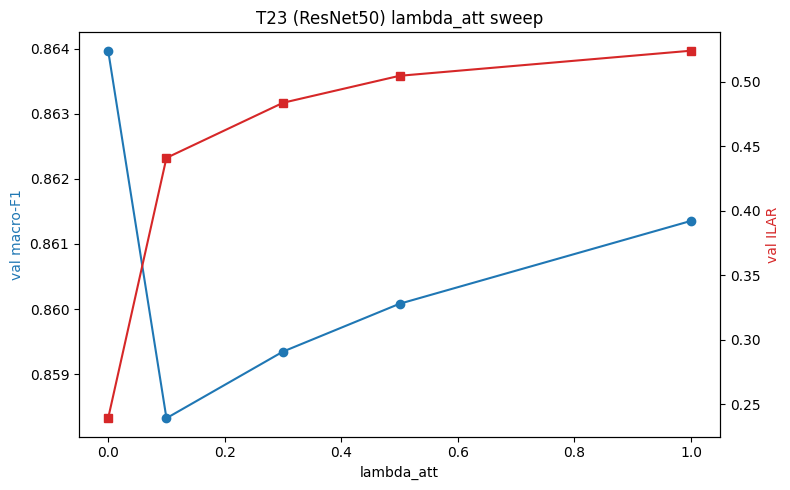

Selected lambda_att* = 1.0


In [24]:
LAMBDA_ATT_STAR = None
if SWEEP_ATT_COMPLETE:
    tuning_df = pd.DataFrame(att_rows)
    tuning_df.to_csv(SWEEP_ROOT / "tuning_summary.csv", index=False)
    display(tuning_df)
    plot_sweep(tuning_df, "lambda_att", "T23 (ResNet50) lambda_att sweep", FIG_DIR / "lambda_att_sweep.png")

    top, ref_f1 = select_largest_within_tolerance(tuning_df, "lambda_att", "lam_att_0.0")
    lambda_att_selected = {
        "name": top["name"], "lambda_att": float(top["lambda_att"]),
        "phase1_lr": float(top["phase1_lr"]), "phase2_lr": float(top["phase2_lr"]),
        "weight_decay": float(top["weight_decay"]), "optimizer": top["optimizer"], "scheduler": top["scheduler"],
        "gate_mode": cfg["module"]["gate_mode"], "target_mode": cfg["module"]["target_mode"],
        "reduction": cfg["module"]["reduction"],
        "rule": "largest lambda_att whose val macro-F1 is within 0.5pp of lam_att_0.0; ties -> higher val ILAR",
        "reference_row": "lam_att_0.0", "reference_val_macro_f1": ref_f1,
        "schedule": f"short({TUNE_PHASE1_EPOCHS}+{TUNE_PHASE2_EPOCHS})", "seed": SEED, "backbone": "resnet50",
        "pipeline": PIPELINE_VERSION,
    }
    (SWEEP_ROOT / "selected_config.json").write_text(json.dumps(lambda_att_selected, indent=2))
    LAMBDA_ATT_STAR = lambda_att_selected["lambda_att"]
    print(f"Selected lambda_att* = {LAMBDA_ATT_STAR}")
else:
    print("lambda_att sweep incomplete -- selection (and everything that needs lambda_att*) waits for a later session.")

## S10 -- Full-schedule runs -- A2, A1, A5, A4, A3 (seed 42)

Priority order as in T18: A2 (headline) -> A1 -> A5 (CBAM comparator) -> A4 -> A3. `run_full_arm`
re-seeds at the start of every arm, and each arm gets its own fresh train loader.

In [25]:
ARM_CONFIGS = {}
if LAMBDA_ATT_STAR is not None:
    _lung = {"module.use_attention": True, "module.attention": "lung", "module.lambda_bg": 0.0}
    ARM_CONFIGS = {
        "A2_full": merge_overrides(cfg, {**_lung, "module.gate_mode": "residual", "module.lambda_att": LAMBDA_ATT_STAR,
                                         "experiment.name": "T23-A2-full"}),
        "A1_gate_only": merge_overrides(cfg, {**_lung, "module.gate_mode": "residual", "module.lambda_att": 0.0,
                                              "experiment.name": "T23-A1-gate-only"}),
        "A5_cbam": merge_overrides(cfg, {"module.use_attention": True, "module.attention": "cbam",
                                         "module.lambda_att": 0.0, "module.lambda_bg": 0.0,  # CBAM is never mask-supervised
                                         "experiment.name": "T23-A5-cbam"}),
        "A4_guidance_only": merge_overrides(cfg, {**_lung, "module.gate_mode": "none", "module.lambda_att": LAMBDA_ATT_STAR,
                                                  "experiment.name": "T23-A4-guidance-only"}),
        "A3_multiply": merge_overrides(cfg, {**_lung, "module.gate_mode": "multiply", "module.lambda_att": LAMBDA_ATT_STAR,
                                             "experiment.name": "T23-A3-multiply"}),
    }
    for arm_name, arm_cfg in ARM_CONFIGS.items():
        train_arm_if_needed(arm_name, arm_cfg, RUNS_ROOT / arm_name)
else:
    print("Waiting on S9's lambda_att* -- A1-A5 run in a later session.")

wandb: setting up run f0lgmvzg
wandb: Tracking run with wandb version 0.26.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260925_050153-f0lgmvzg
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run resnet50_T18-A2_full_seed42
wandb: ⭐️ View project at https://wandb.ai/sinethwickramaratna-university-of-moratuwa/chest-xray-disease-classification
wandb: 🚀 View run at https://wandb.ai/sinethwickramaratna-university-of-moratuwa/chest-xray-disease-classification/runs/f0lgmvzg


[phase1_frozen] epoch 1/15 train_loss=1.2505 (cls=0.8463, att=0.4042) train_acc=0.6732 | val_loss=1.0423 (cls=0.6731, att=0.3692) val_acc=0.7720 val_f1=0.7509 val_ilar=0.4517


[phase1_frozen] epoch 2/15 train_loss=0.9999 (cls=0.6297, att=0.3702) train_acc=0.7356 | val_loss=0.9474 (cls=0.5898, att=0.3577) val_acc=0.7899 val_f1=0.7758 val_ilar=0.4652


[phase1_frozen] epoch 3/15 train_loss=0.9361 (cls=0.5737, att=0.3624) train_acc=0.7623 | val_loss=0.9011 (cls=0.5516, att=0.3495) val_acc=0.8038 val_f1=0.7906 val_ilar=0.4905


[phase1_frozen] epoch 4/15 train_loss=0.8949 (cls=0.5377, att=0.3572) train_acc=0.7754 | val_loss=0.8668 (cls=0.5201, att=0.3467) val_acc=0.8161 val_f1=0.8068 val_ilar=0.4836


...

[phase2_finetune] epoch 35/40 train_loss=0.4889 (cls=0.2032, att=0.2857) train_acc=0.9107 | val_loss=0.5418 (cls=0.2641, att=0.2777) val_acc=0.9074 val_f1=0.9135 val_ilar=0.5748


[phase2_finetune] epoch 36/40 train_loss=0.4854 (cls=0.1998, att=0.2856) train_acc=0.9057 | val_loss=0.5348 (cls=0.2572, att=0.2776) val_acc=0.9068 val_f1=0.9121 val_ilar=0.5737


[phase2_finetune] epoch 37/40 train_loss=0.4880 (cls=0.2026, att=0.2854) train_acc=0.9071 | val_loss=0.5392 (cls=0.2616, att=0.2776) val_acc=0.9074 val_f1=0.9132 val_ilar=0.5755
[phase2_finetune] Early stopping at epoch 37 (no improvement for 5 epochs).

=== Test set performance ===
Test accuracy: 0.9134
                 precision    recall  f1-score   support

          COVID     0.8969    0.9151    0.9059       542
   Lung_Opacity     0.9255    0.8681    0.8959       902
         Normal     0.9098    0.9366    0.9230      1529
Viral Pneumonia     0.9356    0.9356    0.9356       202

       accuracy                         0.9134      3175
      macro avg     0.9170    0.9139    0.9151      3175
   weighted avg     0.9137    0.9134    0.9132      3175

Confusion matrix:
 [[ 496   12   32    2]
 [  20  783   99    0]
 [  37   49 1432   11]
 [   0    2   11  189]]
Macro ROC-AUC: 0.9866
Attention ILAR: 0.5735 | Dice: 0.7747 | IoU: 0.6391


wandb: updating run metadata
wandb: 
wandb: Run history:
wandb:          epoch ▁▁▁▂▂▂▂▃▃▃▃▄▄▁▁▂▂▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▆▆▇▇▇██
wandb:  learning_rate ██▇▇▆▅▄▃▃▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb: train_att_loss █▇▇▇▆▆▆▆▆▆▆▆▆▅▅▄▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:  train_bg_loss ██▇▇▇▇▇▇▇▇▇▆▅▄▄▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb: train_cls_loss █▆▅▅▅▄▄▄▄▄▄▄▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:     train_loss █▆▅▅▅▄▄▄▄▄▄▄▄▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:   val_accuracy ▁▁▃▃▃▃▃▃▃▃▃▃▄▅▅▆▆▆▆▆▇▇▇▇█▇▇█████████████
wandb:   val_att_loss █▇▇▇▇▇▆▆▆▆▆▆▅▅▄▄▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:    val_bg_loss ██▆▇▆▆▆▆▆▆▆▆▆▄▄▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:   val_cls_loss █▆▆▅▅▅▅▅▅▅▅▅▅▄▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:             +5 ...
wandb: 
wandb: Run summary:
wandb:                         epoch 37
wandb:                 learning_rate 0.0
wandb:      phase1_frozen_best_epoch 13
wandb:     phase1_frozen_best_val_f1 0.79285
wandb:   phase1_frozen_best_val_loss 0.93393
wandb:    phase2_finetune_best_epoch 32
wandb:  

[timing] arm took 33.5 min; 7.26h left in this session.


## S11 -- lambda_bg sweep (short schedule) + pre-registered selection (design doc section 5b)

Independent second sweep: `lambda_att` fixed at `lambda_att*`, residual gate, `lambda_bg` over
`{0, 0.1, 0.3, 0.5, 1.0}`; largest value within 0.5pp of `lambda_bg=0` (plain A2), ties -> higher ILAR.

In [26]:
LAMBDA_BG_GRID = [0.0, 0.1, 0.3, 0.5, 1.0]
bg_rows, SWEEP_BG_COMPLETE = [], False
if LAMBDA_ATT_STAR is not None:
    bg_rows = [run_sweep_config_if_needed(f"lam_bg_{lam}", lambda_att=LAMBDA_ATT_STAR, lambda_bg=lam) for lam in LAMBDA_BG_GRID]
    SWEEP_BG_COMPLETE = all(r is not None for r in bg_rows)
    print(f"lambda_bg sweep: {sum(r is not None for r in bg_rows)}/{len(bg_rows)} configs done.")
else:
    print("Waiting on S9's lambda_att* -- the lambda_bg sweep runs in a later session.")

wandb: setting up run uybjafbt
wandb: Tracking run with wandb version 0.26.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260925_073916-uybjafbt
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run resnet50_T23-sweep-lam_bg_0.0_seed42
wandb: ⭐️ View project at https://wandb.ai/sinethwickramaratna-university-of-moratuwa/chest-xray-disease-classification
wandb: 🚀 View run at https://wandb.ai/sinethwickramaratna-university-of-moratuwa/chest-xray-disease-classification/runs/uybjafbt


[phase1_frozen] epoch 1/4 train_loss=1.2505 (cls=0.8463, att=0.4042) train_acc=0.6732 | val_loss=1.0423 (cls=0.6731, att=0.3692) val_acc=0.7720 val_f1=0.7509 val_ilar=0.4517


[phase1_frozen] epoch 2/4 train_loss=1.0041 (cls=0.6336, att=0.3705) train_acc=0.7363 | val_loss=0.9539 (cls=0.5960, att=0.3579) val_acc=0.7893 val_f1=0.7741 val_ilar=0.4652


[phase1_frozen] epoch 3/4 train_loss=0.9490 (cls=0.5858, att=0.3633) train_acc=0.7596 | val_loss=0.9451 (cls=0.5933, att=0.3518) val_acc=0.7890 val_f1=0.7746 val_ilar=0.4808


[phase1_frozen] epoch 4/4 train_loss=0.9229 (cls=0.5634, att=0.3595) train_acc=0.7690 | val_loss=0.9124 (cls=0.5627, att=0.3497) val_acc=0.8025 val_f1=0.7908 val_ilar=0.4797


...

[phase2_finetune] epoch 5/6 train_loss=0.8178 (cls=0.3869, att=0.3442) train_acc=0.8319 | val_loss=0.8228 (cls=0.4052, att=0.3344) val_acc=0.8580 val_f1=0.8612 val_ilar=0.5755


wandb: updating run metadata


[phase2_finetune] epoch 6/6 train_loss=0.8088 (cls=0.3787, att=0.3433) train_acc=0.8321 | val_loss=0.8255 (cls=0.4086, att=0.3343) val_acc=0.8542 val_f1=0.8580 val_ilar=0.5764
[timing] sweep_cfg took 6.5 min; 6.71h left in this session.


wandb: uploading history steps 9-9, summary, console lines 0-0
wandb: 
wandb: Run history:
wandb:          epoch ▁▂▄▅▁▂▄▅▇█
wandb:  learning_rate █▅▂▁▁▁▁▁▁▁
wandb: train_att_loss █▅▄▄▃▂▂▁▁▁
wandb:  train_bg_loss █▄▃▃▃▂▁▁▁▁
wandb: train_cls_loss █▅▄▄▃▂▂▁▁▁
wandb:     train_loss █▅▄▄▃▂▂▁▁▁
wandb:   val_accuracy ▁▃▂▃▅▇▇▇██
wandb:   val_att_loss █▆▆▆▄▂▂▁▁▁
wandb:    val_bg_loss █▇▅▆▃▂▂▁▁▁
wandb:   val_cls_loss █▆▆▅▃▂▁▁▁▁
wandb:             +5 ...
wandb: 
wandb: Run summary:
wandb:                         epoch 6
wandb:                 learning_rate 0
wandb:      phase1_frozen_best_epoch 4
wandb:     phase1_frozen_best_val_f1 0.78676
wandb:   phase1_frozen_best_val_loss 1.03359
wandb:    phase2_finetune_best_epoch 5
wandb:   phase2_finetune_best_val_f1 0.86116
wandb: phase2_finetune_best_val_loss 0.8228
wandb:                train_att_loss 0.34332
wandb:                 train_bg_loss 0.08679
wandb:                           +11 ...
wandb: 
wandb: 🚀 View run resnet50_T23-sweep-lam_bg_1.0_see

lambda_bg sweep: 5/5 configs done.


,name,lambda_att,lambda_bg,phase1_lr,phase2_lr,weight_decay,optimizer,scheduler,best_epoch,best_val_loss,val_acc_at_best_loss,val_macro_f1_at_best,val_ilar_at_best
0,lam_bg_0.0,1.0,0.0,0.001,0.00005,0.0001,adamw,cosine,5,0.724047,0.857953,0.861355,0.523900
1,lam_bg_0.1,1.0,0.1,0.001,0.00005,0.0001,adamw,cosine,5,0.735915,0.857953,0.861203,0.531301
2,lam_bg_0.3,1.0,0.3,0.001,0.00005,0.0001,adamw,cosine,5,0.758211,0.858583,0.861845,0.544437
3,lam_bg_0.5,1.0,0.5,0.001,0.00005,0.0001,adamw,cosine,5,0.778506,0.857323,0.860886,0.554900
4,lam_bg_1.0,1.0,1.0,0.001,0.00005,0.0001,adamw,cosine,5,0.822798,0.857953,0.861164,0.575537


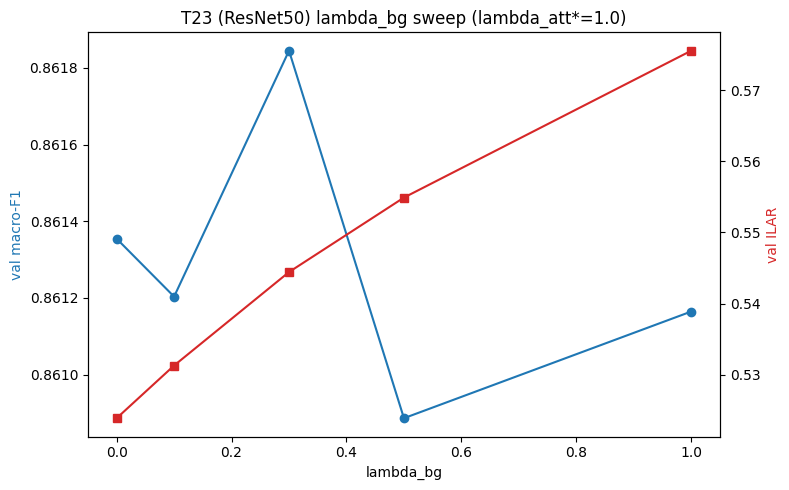

Selected lambda_bg* = 1.0


In [27]:
LAMBDA_BG_STAR = None
if SWEEP_BG_COMPLETE:
    tuning_bg_df = pd.DataFrame(bg_rows)
    tuning_bg_df.to_csv(SWEEP_ROOT / "tuning_summary_bg.csv", index=False)
    display(tuning_bg_df)
    plot_sweep(tuning_bg_df, "lambda_bg", f"T23 (ResNet50) lambda_bg sweep (lambda_att*={LAMBDA_ATT_STAR})",
               FIG_DIR / "lambda_bg_sweep.png")

    top, ref_f1 = select_largest_within_tolerance(tuning_bg_df, "lambda_bg", "lam_bg_0.0")
    lambda_bg_selected = {
        "name": top["name"], "lambda_bg": float(top["lambda_bg"]), "lambda_att": float(LAMBDA_ATT_STAR),
        "gate_mode": "residual", "phase1_lr": float(top["phase1_lr"]), "phase2_lr": float(top["phase2_lr"]),
        "weight_decay": float(top["weight_decay"]), "optimizer": top["optimizer"], "scheduler": top["scheduler"],
        "target_mode": cfg["module"]["target_mode"], "reduction": cfg["module"]["reduction"],
        "rule": "largest lambda_bg whose val macro-F1 is within 0.5pp of lam_bg_0.0 (plain A2); ties -> higher val ILAR",
        "reference_row": "lam_bg_0.0", "reference_val_macro_f1": ref_f1,
        "schedule": f"short({TUNE_PHASE1_EPOCHS}+{TUNE_PHASE2_EPOCHS})", "seed": SEED, "backbone": "resnet50",
        "pipeline": PIPELINE_VERSION,
    }
    (SWEEP_ROOT / "selected_bg_config.json").write_text(json.dumps(lambda_bg_selected, indent=2))
    LAMBDA_BG_STAR = lambda_bg_selected["lambda_bg"]
    print(f"Selected lambda_bg* = {LAMBDA_BG_STAR}")
else:
    print("lambda_bg sweep incomplete -- A6 waits for a later session.")

## S12 -- Arm A6 (A2 + background suppression, full schedule)

Uses `lambda_att*` (S9) and `lambda_bg*` (S11) with the residual gate -- the seventh and final arm.

In [28]:
a6_cfg = None
if LAMBDA_ATT_STAR is not None and LAMBDA_BG_STAR is not None:
    a6_cfg = merge_overrides(cfg, {
        "module.use_attention": True, "module.attention": "lung", "module.gate_mode": "residual",
        "module.lambda_att": LAMBDA_ATT_STAR, "module.lambda_bg": LAMBDA_BG_STAR,
        "experiment.name": "T23-A6-full-bg",
    })
    train_arm_if_needed("A6_full_bg", a6_cfg, RUNS_ROOT / "A6_full_bg")
else:
    print("Waiting on both sweeps -- A6 runs in a later session.")

ALL_ARMS = ["A0_vanilla", "A1_gate_only", "A2_full", "A3_multiply", "A4_guidance_only", "A5_cbam", "A6_full_bg"]
ARM_DIRS = {a: RUNS_ROOT / a for a in ALL_ARMS}
_missing = [a for a in ALL_ARMS if not is_done(ARM_DIRS[a])]
ALL_ARMS_DONE = not _missing
print("All 7 arms trained (acceptance criterion A5)." if ALL_ARMS_DONE else f"Arms still to train: {_missing}")
if a6_cfg is not None:
    ALL_ARM_CONFIGS = {"A0_vanilla": a0_cfg, **ARM_CONFIGS, "A6_full_bg": a6_cfg}

wandb: setting up run pti0wwwy
wandb: Tracking run with wandb version 0.26.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260925_081303-pti0wwwy
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run resnet50_T18-A6_full_bg_seed42
wandb: ⭐️ View project at https://wandb.ai/sinethwickramaratna-university-of-moratuwa/chest-xray-disease-classification
wandb: 🚀 View run at https://wandb.ai/sinethwickramaratna-university-of-moratuwa/chest-xray-disease-classification/runs/pti0wwwy


[phase1_frozen] epoch 1/15 train_loss=1.4022 (cls=0.8559, att=0.4225) train_acc=0.6729 | val_loss=1.1649 (cls=0.6792, att=0.3833) val_acc=0.7682 val_f1=0.7460 val_ilar=0.4979


[phase1_frozen] epoch 2/15 train_loss=1.1266 (cls=0.6374, att=0.3885) train_acc=0.7349 | val_loss=1.0689 (cls=0.5972, att=0.3719) val_acc=0.7874 val_f1=0.7712 val_ilar=0.5146


[phase1_frozen] epoch 3/15 train_loss=1.0609 (cls=0.5803, att=0.3808) train_acc=0.7600 | val_loss=1.0223 (cls=0.5590, att=0.3698) val_acc=0.8013 val_f1=0.7881 val_ilar=0.5335


[phase1_frozen] epoch 4/15 train_loss=1.0176 (cls=0.5430, att=0.3751) train_acc=0.7730 | val_loss=0.9861 (cls=0.5251, att=0.3590) val_acc=0.8145 val_f1=0.8042 val_ilar=0.5272


...

[phase2_finetune] epoch 35/40 train_loss=0.5522 (cls=0.1881, att=0.2884) train_acc=0.9155 | val_loss=0.6006 (cls=0.2465, att=0.2806) val_acc=0.9140 val_f1=0.9202 val_ilar=0.6355


[phase2_finetune] epoch 36/40 train_loss=0.5459 (cls=0.1818, att=0.2881) train_acc=0.9145 | val_loss=0.5944 (cls=0.2404, att=0.2799) val_acc=0.9121 val_f1=0.9184 val_ilar=0.6349


[phase2_finetune] epoch 37/40 train_loss=0.5507 (cls=0.1868, att=0.2883) train_acc=0.9134 | val_loss=0.5974 (cls=0.2435, att=0.2809) val_acc=0.9140 val_f1=0.9213 val_ilar=0.6365
[phase2_finetune] Early stopping at epoch 37 (no improvement for 5 epochs).

=== Test set performance ===
Test accuracy: 0.9200
                 precision    recall  f1-score   support

          COVID     0.9164    0.9299    0.9231       542
   Lung_Opacity     0.9292    0.8736    0.9006       902
         Normal     0.9126    0.9424    0.9273      1529
Viral Pneumonia     0.9495    0.9307    0.9400       202

       accuracy                         0.9200      3175
      macro avg     0.9269    0.9192    0.9227      3175
   weighted avg     0.9203    0.9200    0.9198      3175

Confusion matrix:
 [[ 504    8   28    2]
 [  15  788   99    0]
 [  30   50 1441    8]
 [   1    2   11  188]]
Macro ROC-AUC: 0.9881
Attention ILAR: 0.6349 | Dice: 0.6720 | IoU: 0.5183


wandb: updating run metadata
wandb: uploading history steps 51-51, summary, console lines 73-95
wandb: 
wandb: Run history:
wandb:          epoch ▁▁▁▂▂▂▂▃▃▃▃▄▄▁▁▂▂▂▂▃▃▃▃▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇██
wandb:  learning_rate ██▇▆▆▄▃▃▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb: train_att_loss █▇▇▇▇▆▆▆▆▆▆▅▄▄▄▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:  train_bg_loss █▅▅▄▄▄▄▄▄▄▄▄▄▄▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb: train_cls_loss █▆▅▅▅▄▄▄▄▄▄▄▄▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:     train_loss █▆▅▅▅▄▄▄▄▄▄▄▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:   val_accuracy ▁▂▃▃▃▄▃▃▃▄▄▄▄▄▅▆▆▆▆▇▇▇▇▇▇▇▇█████████████
wandb:   val_att_loss ██▇▇▇▇▇▇▆▇▆▅▅▄▄▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:    val_bg_loss █▇▆█▇▆▆▆▆▇▆▆▆▅▄▄▃▃▃▃▃▂▂▂▂▂▂▁▁▂▂▁▁▁▁▂▁▁▁▁
wandb:   val_cls_loss █▇▆▆▅▅▅▅▅▅▅▅▄▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:             +5 ...
wandb: 
wandb: Run summary:
wandb:                         epoch 37
wandb:                 learning_rate 0.0
wandb:      phase1_frozen_best_epoch 11
wandb:     phase1_frozen_best_val_f1 0.81833
wandb:   phase1_frozen_bes

[timing] arm took 33.7 min; 6.12h left in this session.
All 7 arms trained (acceptance criterion A5).


## S13 -- Evaluation, faithfulness, comparison table (all 7 arms)

Runs once all 7 arms are trained. Per arm: per-image predictions + Grad-CAM EIL at both taps on a
fixed stratified 1,000-image test subset (same images for every arm), each arm a resumable unit.
The comparison table has T18's schema plus a `lambda_bg` column (otherwise A6 and A2 rows look
identical).

In [29]:
from src.modules import stratified_cam_subset, build_per_image_predictions, build_comparison_table, check_acceptance_criteria

EVAL_READY = False
CAM_N = 1000


def load_arm_model(ckpt_path):
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    m = ckpt["config"]["module"]
    model = build_model(
        num_classes=ckpt["config"]["model"]["num_classes"], use_attention=m["use_attention"],
        attention=m.get("attention", "lung"), gate_mode=m.get("gate_mode", "residual"), reduction=m.get("reduction", 8),
        backbone_name="resnet50", pretrained=False, drop_rate=ckpt["config"]["model"].get("drop_rate", 0.0),
    ).to(device)
    model.load_state_dict(ckpt["model_state_dict"])
    return model.eval(), ckpt.get("class_names", class_names)


def evaluate_arm_if_needed(arm_name, arm_dir):
    # Returns an arms_for_table entry, or None if deferred by the budget.
    arm_dir = Path(arm_dir)
    marker = arm_dir / EVAL_MARKER
    fresh = _marker_ok(marker) and json.loads(marker.read_text()).get("cam_n") == len(cam_subset)
    if fresh:
        per_image_df = pd.read_csv(arm_dir / "per_image_predictions.csv")
    else:
        if not can_start("eval_arm", arm_name):
            return None
        with timed("eval_arm"):
            model, arm_class_names = load_arm_model(arm_dir / f"resnet50_{arm_name}.pt")
            per_image_df = build_per_image_predictions(
                model, datasets["test"], arm_class_names, device, cam_subset=cam_subset, backbone_name="resnet50")
            per_image_df.to_csv(arm_dir / "per_image_predictions.csv", index=False)
            del model; gc.collect(); torch.cuda.empty_cache()
        marker.write_text(json.dumps({"pipeline": PIPELINE_VERSION, "cam_n": len(cam_subset)}))

    info = read_done(arm_dir)
    evaluate_results = json.loads((arm_dir / "phase2_finetune_test_results.json").read_text())
    summary = {
        "attention_ilar": evaluate_results.get("attention_ilar"),
        "attention_dice": evaluate_results.get("attention_dice"),
        "attention_iou": evaluate_results.get("attention_iou"),
        "cam_eil_post_mean": float(per_image_df["eil_post"].mean()) if per_image_df["eil_post"].notna().any() else None,
        "cam_eil_pre_mean": float(per_image_df["eil_pre"].mean()) if per_image_df["eil_pre"].notna().any() else None,
        "cam_subset_n": len(cam_subset),
    }
    (arm_dir / "attention_metrics.json").write_text(json.dumps(summary, indent=2))
    gate = "none" if not info["use_attention"] else ("cbam" if info["attention"] == "cbam" else info["gate_mode"])
    return {"gate_mode": gate, "lambda_att": info["lambda_att"], "lambda_bg": info["lambda_bg"],
            "evaluate_results": evaluate_results, "per_image_df": per_image_df}


if ALL_ARMS_DONE:
    cam_subset = stratified_cam_subset(datasets["test"], n=CAM_N, seed=SEED)
    (T23_ROOT / "cam_subset_indices.json").write_text(
        json.dumps({"n": len(cam_subset), "seed": SEED, "positions": cam_subset.tolist()}, indent=2))
    print(f"Grad-CAM subsample: {len(cam_subset)} / {len(datasets['test'])} test images")

    arms_for_table = {}
    for arm_name in ALL_ARMS:
        entry = evaluate_arm_if_needed(arm_name, ARM_DIRS[arm_name])
        if entry is not None:
            arms_for_table[arm_name] = entry
    EVAL_READY = len(arms_for_table) == len(ALL_ARMS)
    print(f"{len(arms_for_table)}/{len(ALL_ARMS)} arms evaluated.")
else:
    print("Evaluation waits until all 7 arms are trained.")

Grad-CAM subsample: 1000 / 3175 test images
[timing] eval_arm took 0.7 min; 6.09h left in this session.
[timing] eval_arm took 0.7 min; 6.08h left in this session.
[timing] eval_arm took 0.7 min; 6.06h left in this session.
[timing] eval_arm took 0.7 min; 6.05h left in this session.
[timing] eval_arm took 0.7 min; 6.04h left in this session.
[timing] eval_arm took 0.7 min; 6.03h left in this session.
[timing] eval_arm took 0.7 min; 6.01h left in this session.
7/7 arms evaluated.


In [30]:
if EVAL_READY:
    comparison_df = build_comparison_table(arms_for_table, reference_arm="A0_vanilla")
    comparison_df.insert(3, "lambda_bg", [arms_for_table[a]["lambda_bg"] for a in comparison_df["arm"]])
    comparison_df.to_csv(T23_ROOT / "T23_comparison_table.csv", index=False)
    display(comparison_df)

    # A1-A4 checked against A2 for direct comparability with T18; S14 picks the actual winner.
    verdicts = check_acceptance_criteria(comparison_df, headline_arm="A2_full")
    for name, v in verdicts.items():
        print(f"[{'PASS' if v['pass'] else 'FAIL'}] {name}: {v['value']:.4f} (target: {v['target']})")
    (T23_ROOT / "acceptance_criteria_A1_A4.json").write_text(json.dumps(verdicts, indent=2))
    print("\nA failing verdict is a legitimate finding to report, not a reason to keep tuning.")
else:
    print("Comparison table waits for evaluation of all 7 arms.")

,arm,gate,lambda,lambda_bg,test_acc,test_macro_f1,test_auc_macro,ILAR,att_dice,EIL_post,EIL_pre,delta_macro_f1,delta_eil_post,delta_eil_pre
0,A0_vanilla,none,0.0,0.0,0.917480,0.918394,0.987548,NaN,NaN,0.361381,0.361381,0.000000,0.000000,0.000000
1,A1_gate_only,residual,0.0,0.0,0.917165,0.918376,0.986806,0.239559,0.382427,0.338812,0.338812,-0.000018,-0.022569,-0.022569
2,A2_full,residual,1.0,0.0,0.918740,0.921548,0.988032,0.591809,0.777938,0.436783,0.381955,0.003154,0.075402,0.020575
3,A3_multiply,multiply,1.0,0.0,0.913386,0.915110,0.986615,0.573496,0.774657,0.660279,0.556841,-0.003284,0.298898,0.195460
4,A4_guidance_only,none,1.0,0.0,0.918110,0.920551,0.988296,0.589209,0.772683,0.381109,0.381109,0.002157,0.019728,0.019728
5,A5_cbam,cbam,0.0,0.0,0.916220,0.917534,0.987185,0.239537,0.382427,0.359465,0.359465,-0.000860,-0.001916,-0.001916
6,A6_full_bg,residual,1.0,1.0,0.920000,0.922733,0.988110,0.634911,0.672032,0.437603,0.383914,0.004339,0.076222,0.022533


[FAIL] A1_attention_matches_lung_mask: 0.7779 (target: Attention-Dice >= 0.80 on test)
[PASS] A2_evidence_inside_lung_up: 0.0754 (target: delta Grad-CAM EIL (post-gate) >= +0.05)
[PASS] A3_mechanism_is_real: 0.0206 (target: delta Grad-CAM EIL (pre-gate) > 0)
[PASS] A4_no_accuracy_tax: 0.0032 (target: delta test macro-F1 >= -1.0pp vs. A0)

A failing verdict is a legitimate finding to report, not a reason to keep tuning.


## S14 -- Winner-selection rule (design doc section 8) -- across all 7 arms

1. Candidate winner iff McNemar p >= 0.05 vs. A0 (no detectable accuracy cost) **and** Wilcoxon
   p < 0.05 on paired EIL_post (a real evidence-relocation effect).
2. Rank candidates by mean EIL_post gain; efficiency (S15) only breaks ties.
3. Reported independently of DenseNet121 -- A2 is not assumed to win, nor A6 to beat A2.

In [31]:
RESNET50_WINNER = None
if EVAL_READY:
    from src.modules import run_significance_tests

    sig_results = run_significance_tests(arms_for_table, reference_arm="A0_vanilla",
                                         output_json=T23_ROOT / "significance_tests_vs_A0.json")
    sig_df = pd.DataFrame(sig_results).T.rename_axis("arm").reset_index()
    display(sig_df)

    candidates = sig_df[sig_df["is_candidate_winner"] == True]
    if candidates.empty:
        print("No arm passes both gates -- a legitimate finding: report sig_df as-is, do not force a winner.")
    else:
        ranked = candidates.sort_values("mean_eil_post_gain", ascending=False)
        print(ranked[["arm", "mean_eil_post_gain", "mcnemar_p", "wilcoxon_p"]].to_string(index=False))
        RESNET50_WINNER = ranked.iloc[0]["arm"]
        print(f"\nResNet50's winner (independent of DenseNet121's A2): {RESNET50_WINNER}")

    (T23_ROOT / "winner_selection.json").write_text(json.dumps({
        "reference_arm": "A0_vanilla",
        "candidates": list(candidates["arm"]),
        "winner": RESNET50_WINNER,
        "rule": "candidate iff McNemar p>=0.05 AND Wilcoxon p<0.05 on EIL_post vs. A0; rank by mean EIL_post gain; "
                "efficiency breaks ties only.",
    }, indent=2))
else:
    print("Winner selection waits for evaluation of all 7 arms.")

,arm,reference_arm,n_test_images_compared,mcnemar_b,mcnemar_c,mcnemar_p,mcnemar_pass_no_accuracy_cost,wilcoxon_n,wilcoxon_stat,wilcoxon_p,wilcoxon_pass_real_eil_effect,mean_eil_post_gain,is_candidate_winner
0,A1_gate_only,A0_vanilla,3175,30,29,1.0,True,1000,38736.0,0.0,True,-0.022569,True
1,A2_full,A0_vanilla,3175,31,35,0.712231,True,1000,5260.0,0.0,True,0.075402,True
2,A3_multiply,A0_vanilla,3175,66,53,0.271248,True,1000,3.0,0.0,True,0.298898,True
3,A4_guidance_only,A0_vanilla,3175,25,27,0.889884,True,1000,66166.0,0.0,True,0.019728,True
4,A5_cbam,A0_vanilla,3175,26,22,0.665466,True,1000,190653.0,0.0,True,-0.001916,True
5,A6_full_bg,A0_vanilla,3175,25,33,0.358143,True,1000,3814.0,0.0,True,0.076222,True


             arm mean_eil_post_gain mcnemar_p wilcoxon_p
     A3_multiply           0.298898  0.271248        0.0
      A6_full_bg           0.076222  0.358143        0.0
         A2_full           0.075402  0.712231        0.0
A4_guidance_only           0.019728  0.889884        0.0
         A5_cbam          -0.001916  0.665466        0.0
    A1_gate_only          -0.022569       1.0        0.0

ResNet50's winner (independent of DenseNet121's A2): A3_multiply


## S15 -- Efficiency measurement (acceptance criterion A6)

Architecture-only (no trained weights), so it runs in the first session and is skipped afterwards.

In [32]:
from src.modules import check_module_efficiency

T23_EFFICIENCY_CSV = T23_ROOT / "T23_efficiency.csv"
A6_JSON = T23_ROOT / "acceptance_criteria_A6.json"

if A6_JSON.exists():
    efficiency_verdicts = json.loads(A6_JSON.read_text())
    print("[resume] efficiency already measured.")
else:
    %pip install -q fvcore
    if str(REPO_ROOT / "notebooks") not in sys.path:
        sys.path.insert(0, str(REPO_ROOT / "notebooks"))
    from efficiency import benchmark_model

    benchmark_model(LogitsOnly(build_model(use_attention=False, pretrained=False, backbone_name="resnet50")),
                    "ResNet50", "without_module", output_csv=T23_EFFICIENCY_CSV)
    benchmark_model(LogitsOnly(build_model(use_attention=True, pretrained=False, backbone_name="resnet50")),
                    "ResNet50", "with_module", output_csv=T23_EFFICIENCY_CSV)
    efficiency_verdicts = check_module_efficiency(pd.read_csv(T23_EFFICIENCY_CSV))
    A6_JSON.write_text(json.dumps(efficiency_verdicts, indent=2))

_v6 = efficiency_verdicts["A6_module_is_cheap"]
print(f"[{'PASS' if _v6['pass'] else 'FAIL'}] A6_module_is_cheap (target: {_v6['target']})")
print(f"  params: +{_v6['params_delta_absolute']:,} ({_v6['params_delta_pct']:.4f}%)")
print(f"  gflops: +{_v6['gflops_delta_absolute']:.6f} ({_v6['gflops_delta_pct']:.4f}%)")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 1.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 1.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.6/129.6 kB 3.9 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.

Efficiency benchmark: ResNet50 [without_module]


Unsupported operator aten::max_pool2d encountered 1 time(s)
Unsupported operator aten::add_ encountered 16 time(s)


Measuring CPU latency...
Measuring GPU latency...

Result:
  model: ResNet50
  module: without_module
  input_shape: 1x3x224x224
  params_total: 23516228
  params_trainable: 23516228
  flops: 4109472768.0000
  gflops: 4.1095
  state_dict_size_mb: 90.0177
  checkpoint_size_mb: None
  cpu_latency_ms: 127.4983
  cpu_throughput_img_s: 7.8432
  gpu_latency_ms: 6.2544
  gpu_throughput_img_s: 159.8878

Saved/appended result to: /kaggle/working/T23_resnet50_lung_attention/T23_efficiency.csv

Efficiency benchmark: ResNet50 [with_module]


Unsupported operator aten::max_pool2d encountered 1 time(s)
Unsupported operator aten::add_ encountered 16 time(s)
Unsupported operator aten::sigmoid encountered 1 time(s)
Unsupported operator aten::add encountered 1 time(s)
Unsupported operator aten::mul encountered 1 time(s)


Measuring CPU latency...
Measuring GPU latency...

Result:
  model: ResNet50
  module: with_module
  input_shape: 1x3x224x224
  params_total: 24041029
  params_trainable: 24041029
  flops: 4135175424.0000
  gflops: 4.1352
  state_dict_size_mb: 92.0210
  checkpoint_size_mb: None
  cpu_latency_ms: 126.5757
  cpu_throughput_img_s: 7.9004
  gpu_latency_ms: 6.1313
  gpu_throughput_img_s: 163.0984

Saved/appended result to: /kaggle/working/T23_resnet50_lung_attention/T23_efficiency.csv
[PASS] A6_module_is_cheap (target: params delta <= 3.0%, GFLOPs delta <= 2.0%)
  params: +524,801 (2.2317%)
  gflops: +0.025703 (0.6254%)


## S16 -- Figures (acceptance criterion A8)

Heat-map overlays (up to 3 per class) comparing A0 vs. A2 (T18's convention) + the A2 attention
grid. The lambda-sweep plots were saved in S9/S11.

In [33]:
if EVAL_READY:
    import torch.nn.functional as TF_f
    from src.modules import select_heatmap_images, plot_heatmap_row, plot_attention_grid

    a0_pi = arms_for_table["A0_vanilla"]["per_image_df"]
    a2_pi = arms_for_table["A2_full"]["per_image_df"]
    heatmap_selection = select_heatmap_images(a0_pi, a2_pi, class_names, n_per_class=3, seed=SEED)

    a0_model, _ = load_arm_model(ARM_DIRS["A0_vanilla"] / "resnet50_A0_vanilla.pt")
    a2_model, _ = load_arm_model(ARM_DIRS["A2_full"] / "resnet50_A2_full.pt")
    a0_tap_post, _ = get_taps(a0_model, backbone_name="resnet50")
    a2_tap_post, _ = get_taps(a2_model, backbone_name="resnet50")

    base_ds = datasets["test"].base_dataset
    path_to_test_idx = {str(base_ds.samples[datasets["test"].indices[i]][0]): i for i in range(len(datasets["test"]))}

    def _gray(img_t):
        return (img_t * std + mean).clamp(0, 1).mean(0).numpy()

    def _a2_attention(img_t):
        with torch.no_grad():
            _, att, _ = a2_model(img_t.unsqueeze(0).to(device))
        return TF_f.interpolate(att.float(), size=(224, 224), mode="bilinear", align_corners=False)[0, 0].cpu().numpy()

    HEATMAP_DIR = FIG_DIR / "heatmaps"
    for _, row in heatmap_selection.iterrows():
        img_t, _label, mask_t = datasets["test"][path_to_test_idx[row["image_path"]]]
        batch = img_t.unsqueeze(0)
        a0_cam, _ = cam_for(a0_model, batch, a0_tap_post, device)
        a2_cam, _ = cam_for(a2_model, batch, a2_tap_post, device)
        plot_heatmap_row(
            image=_gray(img_t), mask=mask_t[0].numpy(), a0_cam=a0_cam[0, 0].cpu().numpy(),
            a2_attention=_a2_attention(img_t), a2_cam=a2_cam[0, 0].cpu().numpy(),
            title=f"{row['class_name']} -- {row['reason']}",
            output_path=HEATMAP_DIR / f"{row['class_name']}_{row['reason']}.png".replace(" ", "_"),
        )
    print(f"Saved {len(heatmap_selection)} heat-map overlay rows to {HEATMAP_DIR}")

    _grid_images, _grid_atts, _grid_labels = [], [], []
    for cname in class_names:
        cls_rows = a2_pi[a2_pi["true_label"] == cname]
        for _, row in cls_rows.sample(min(4, len(cls_rows)), random_state=SEED).iterrows():
            img_t, _label, _mask = datasets["test"][path_to_test_idx[row["image_path"]]]
            _grid_images.append(_gray(img_t)); _grid_atts.append(_a2_attention(img_t)); _grid_labels.append(cname)
    plot_attention_grid(_grid_images, _grid_atts, _grid_labels, class_names, output_path=FIG_DIR / "attention_grid.png")
    del a0_model, a2_model; gc.collect(); torch.cuda.empty_cache()
    print(f"Saved attention grid to {FIG_DIR / 'attention_grid.png'}")
else:
    print("Figures wait for evaluation of all 7 arms.")

Saved 12 heat-map overlay rows to /kaggle/working/T23_resnet50_lung_attention/figures/heatmaps
Saved attention grid to /kaggle/working/T23_resnet50_lung_attention/figures/attention_grid.png


## S17 -- Multi-seed repeat (design doc step 8)

Only if S14 found a clear winner: A0 and the winner at seeds 123 and 2026, full schedule, then the
same evaluation. Each run and each evaluation is resumable. With no winner (or `RUN_MULTISEED =
False`), an explicit single-seed statement is recorded instead -- never while repeats are merely
pending.

In [34]:
RUN_MULTISEED = True
MULTISEED_SEEDS = [123, 2026]
MULTISEED_ROOT = T23_ROOT / "runs_multiseed"
MULTISEED_SUMMARY_PATH = MULTISEED_ROOT / "multiseed_summary.json"
multiseed_summary = None

if not EVAL_READY:
    print("Multi-seed repeat is decided after evaluation of all 7 arms.")
elif not RUN_MULTISEED or RESNET50_WINNER is None:
    _reason = "no arm passed the winner-selection rule (S14)" if RESNET50_WINNER is None else "RUN_MULTISEED = False"
    MULTISEED_ROOT.mkdir(parents=True, exist_ok=True)
    MULTISEED_SUMMARY_PATH.write_text(json.dumps({
        "multiseed_repeat_run": False, "seed": SEED, "reason": _reason,
        "statement": ("All T23 (ResNet50) results are single-seed (42) point estimates; the design doc's step-8 "
                      f"multi-seed repeat was not run because {_reason}. No mean +/- std is reported."),
    }, indent=2))
    print(f"Single-seed statement recorded ({_reason}).")
else:
    _seed_dirs = {}
    for seed in MULTISEED_SEEDS:
        for arm_name in ["A0_vanilla", RESNET50_WINNER]:
            run_name = f"{arm_name}_seed{seed}"
            seed_cfg = merge_overrides(ALL_ARM_CONFIGS[arm_name], {"experiment.seed": seed, "experiment.name": f"T23-{run_name}"})
            _seed_dirs[(arm_name, seed)] = MULTISEED_ROOT / run_name
            train_arm_if_needed(run_name, seed_cfg, MULTISEED_ROOT / run_name)

    if all(is_done(d) for d in _seed_dirs.values()):
        per_seed_comparison_dfs = {SEED: comparison_df}
        for seed in MULTISEED_SEEDS:
            seed_table = {}
            for arm_name in ["A0_vanilla", RESNET50_WINNER]:
                entry = evaluate_arm_if_needed(f"{arm_name}_seed{seed}", _seed_dirs[(arm_name, seed)])
                if entry is not None:
                    seed_table[arm_name] = entry
            if len(seed_table) == 2:
                per_seed_comparison_dfs[seed] = build_comparison_table(
                    seed_table, reference_arm="A0_vanilla", output_csv=MULTISEED_ROOT / f"T23_comparison_table_seed{seed}.csv")

        if len(per_seed_comparison_dfs) == 1 + len(MULTISEED_SEEDS):
            from src.modules import summarize_multiseed
            multiseed_summary = summarize_multiseed(per_seed_comparison_dfs, arms=["A0_vanilla", RESNET50_WINNER],
                                                    metrics=["test_macro_f1", "EIL_post"])
            for arm_name, metrics in multiseed_summary.items():
                for metric, s in metrics.items():
                    print(f"{arm_name} {metric}: {s['mean']:.4f} +/- {s['std']:.4f} (seeds {s['seeds']})")
            MULTISEED_SUMMARY_PATH.write_text(json.dumps(multiseed_summary, indent=2))
        else:
            print("Multi-seed evaluation incomplete -- continues next session.")
    else:
        print("Multi-seed training incomplete -- continues next session.")

wandb: setting up run zxn8pc2y
wandb: Tracking run with wandb version 0.26.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260925_085843-zxn8pc2y
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run resnet50_T18-A0_vanilla_seed123_seed123
wandb: ⭐️ View project at https://wandb.ai/sinethwickramaratna-university-of-moratuwa/chest-xray-disease-classification
wandb: 🚀 View run at https://wandb.ai/sinethwickramaratna-university-of-moratuwa/chest-xray-disease-classification/runs/zxn8pc2y


[phase1_frozen] epoch 1/15 train_loss=0.9077 (cls=0.9077, att=0.0000) train_acc=0.6476 | val_loss=0.7102 (cls=0.7102, att=0.0000) val_acc=0.7622 val_f1=0.7403 val_ilar=nan


[phase1_frozen] epoch 2/15 train_loss=0.6575 (cls=0.6575, att=0.0000) train_acc=0.7316 | val_loss=0.6318 (cls=0.6318, att=0.0000) val_acc=0.7761 val_f1=0.7551 val_ilar=nan


[phase1_frozen] epoch 3/15 train_loss=0.6012 (cls=0.6012, att=0.0000) train_acc=0.7542 | val_loss=0.6041 (cls=0.6041, att=0.0000) val_acc=0.7789 val_f1=0.7719 val_ilar=nan


[phase1_frozen] epoch 4/15 train_loss=0.5726 (cls=0.5726, att=0.0000) train_acc=0.7631 | val_loss=0.5400 (cls=0.5400, att=0.0000) val_acc=0.8104 val_f1=0.7982 val_ilar=nan


...

[phase2_finetune] epoch 38/40 train_loss=0.4889 (cls=0.2004, att=0.2885) train_acc=0.9085 | val_loss=0.5376 (cls=0.2566, att=0.2810) val_acc=0.9074 val_f1=0.9140 val_ilar=0.5685


[phase2_finetune] epoch 39/40 train_loss=0.4861 (cls=0.1970, att=0.2891) train_acc=0.9087 | val_loss=0.5449 (cls=0.2639, att=0.2809) val_acc=0.9055 val_f1=0.9116 val_ilar=0.5688


[phase2_finetune] epoch 40/40 train_loss=0.4882 (cls=0.1994, att=0.2888) train_acc=0.9091 | val_loss=0.5389 (cls=0.2579, att=0.2810) val_acc=0.9065 val_f1=0.9129 val_ilar=0.5699

=== Test set performance ===
Test accuracy: 0.9159
                 precision    recall  f1-score   support

          COVID     0.8887    0.9280    0.9079       542
   Lung_Opacity     0.9343    0.8670    0.8994       902
         Normal     0.9151    0.9372    0.9260      1529
Viral Pneumonia     0.9223    0.9406    0.9314       202

       accuracy                         0.9159      3175
      macro avg     0.9151    0.9182    0.9162      3175
   weighted avg     0.9165    0.9159    0.9157      3175

Confusion matrix:
 [[ 503    9   28    2]
 [  25  782   95    0]
 [  38   44 1433   14]
 [   0    2   10  190]]
Macro ROC-AUC: 0.9870
Attention ILAR: 0.5686 | Dice: 0.7670 | IoU: 0.6286


wandb: updating run metadata
wandb: 
wandb: Run history:
wandb:          epoch ▁▁▂▂▂▂▃▃▃▃▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇▇██
wandb:  learning_rate ██▇▆▅▃▃▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb: train_att_loss █▇▇▇▆▆▆▆▆▆▆▅▅▄▄▃▃▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:  train_bg_loss ███▇▇▇▇▇▇▇▆▅▄▄▄▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb: train_cls_loss █▆▅▄▄▄▄▄▄▄▄▄▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:     train_loss █▅▅▅▅▄▄▄▄▄▄▄▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:   val_accuracy ▁▂▃▃▃▄▄▄▄▄▅▅▅▆▆▇▇▇▇▇▇█▇█████████████████
wandb:   val_att_loss █▇▇▇▆▆▆▆▆▅▄▄▄▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:    val_bg_loss █▇▇▆▇▇▅▆▇▇▆▆▆▅▄▃▃▃▂▂▂▂▁▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:   val_cls_loss █▇▇▆▆▆▆▆▆▆▆▄▄▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:             +5 ...
wandb: 
wandb: Run summary:
wandb:                         epoch 40
wandb:                 learning_rate 0
wandb:      phase1_frozen_best_epoch 14
wandb:     phase1_frozen_best_val_f1 0.79658
wandb:   phase1_frozen_best_val_loss 0.93928
wandb:    phase2_finetune_best_epoch 38
wandb:   p

[timing] arm took 35.8 min; 3.68h left in this session.
[timing] eval_arm took 0.7 min; 3.67h left in this session.
[timing] eval_arm took 0.7 min; 3.65h left in this session.
[timing] eval_arm took 0.7 min; 3.64h left in this session.
[timing] eval_arm took 0.7 min; 3.63h left in this session.
A0_vanilla test_macro_f1: 0.9206 +/- 0.0022 (seeds [42, 123, 2026])
A0_vanilla EIL_post: 0.3571 +/- 0.0046 (seeds [42, 123, 2026])
A3_multiply test_macro_f1: 0.9154 +/- 0.0007 (seeds [42, 123, 2026])
A3_multiply EIL_post: 0.6560 +/- 0.0037 (seeds [42, 123, 2026])


## S18 -- Package and hand off

Generates a first-draft `T23_module_card.md` from the computed results -- review and edit by hand
before treating it as final, as with T18's card.

In [35]:
if EVAL_READY:
    def _table_md(df):
        try:
            return df.to_markdown(index=False)
        except ImportError:  # tabulate not installed
            return "```\n" + df.to_string(index=False) + "\n```"

    lines = [
        "# T23 -- Lung-Region Attention Module on ResNet50 -- Module Card\n",
        "**Backbone:** ResNet50 (timm, ImageNet-pretrained). **Draft auto-generated by S18 -- review before treating as final.**\n",
        "## 1. Selected hyperparameters\n",
        f"- `lambda_att*` = {LAMBDA_ATT_STAR} (S9; {lambda_att_selected['rule']})",
        f"- `lambda_bg*` = {LAMBDA_BG_STAR} (S11; {lambda_bg_selected['rule']})",
        f"- `reduction` = {cfg['module']['reduction']} -> +524,801 params (+2.23% of ResNet50's 23,516,228)\n",
        "## 2. Comparison table (all 7 arms, seed 42)\n",
        _table_md(comparison_df), "",
        "## 3. Acceptance criteria A1-A4 (headline arm: A2_full)\n",
        *[f"- **[{'PASS' if v['pass'] else 'FAIL'}]** {k}: {v['value']:.4f} (target: {v['target']})" for k, v in verdicts.items()],
        "",
        "## 4. Acceptance criterion A6 (module cost)\n",
        f"- **[{'PASS' if _v6['pass'] else 'FAIL'}]** params +{_v6['params_delta_absolute']:,} ({_v6['params_delta_pct']:.4f}%), "
        f"GFLOPs +{_v6['gflops_delta_absolute']:.6f} ({_v6['gflops_delta_pct']:.4f}%)\n",
        "## 5. Winner selection (design doc section 8)\n",
        f"Candidates (McNemar p>=0.05 AND Wilcoxon p<0.05 vs. A0): {list(candidates['arm']) or '(none)'}",
        f"**ResNet50's winner: {RESNET50_WINNER or 'none -- no arm passed both gates, see significance_tests_vs_A0.json'}**\n",
        "## 6. Multi-seed repeat\n",
        (json.dumps(multiseed_summary, indent=2) if multiseed_summary is not None
         else (json.loads(MULTISEED_SUMMARY_PATH.read_text()).get("statement", "pending")
               if MULTISEED_SUMMARY_PATH.exists() else "pending")),
        "",
        "## 7. Reproducibility notes\n",
        f"- Data pipeline `{PIPELINE_VERSION}`: RAM-cached inputs (bit-identical to disk), a fresh seeded train "
        "loader per run, so each arm is reproducible regardless of which session it ran in.",
        "- Checkpoints (`.pt`) are not committed -- record their Kaggle Dataset / Drive URLs here.",
    ]
    (T23_ROOT / "T23_module_card.md").write_text("\n".join(lines), encoding="utf-8")
    print(f"Draft module card written to {T23_ROOT / 'T23_module_card.md'}")
else:
    print("Module card waits for evaluation of all 7 arms.")

Draft module card written to /kaggle/working/T23_resnet50_lung_attention/T23_module_card.md


## Progress report

What's finished, what's left, and what to do next.

In [36]:
def _eval_done(d):
    return _marker_ok(Path(d) / EVAL_MARKER)

units = [("S7 checks", is_done(T23_ROOT / "smoke_test"))]
units += [(f"sweep lam_att_{lam}", is_done(SWEEP_ROOT / f"lam_att_{lam}")) for lam in LAMBDA_ATT_GRID]
units += [(f"train {a}", is_done(ARM_DIRS[a])) for a in ALL_ARMS]
units += [(f"sweep lam_bg_{lam}", is_done(SWEEP_ROOT / f"lam_bg_{lam}")) for lam in LAMBDA_BG_GRID]
units += [(f"evaluate {a}", _eval_done(ARM_DIRS[a])) for a in ALL_ARMS]
units += [("efficiency (A6)", A6_JSON.exists())]
if EVAL_READY and RUN_MULTISEED and RESNET50_WINNER is not None:
    for seed in MULTISEED_SEEDS:
        for arm_name in ["A0_vanilla", RESNET50_WINNER]:
            d = MULTISEED_ROOT / f"{arm_name}_seed{seed}"
            units += [(f"train {arm_name} seed{seed}", is_done(d)), (f"evaluate {arm_name} seed{seed}", _eval_done(d))]
elif not EVAL_READY:
    units += [("multi-seed repeat (decided after evaluation)", False)]

remaining = [name for name, done in units if not done]
for name, done in units:
    print(f"  [{'x' if done else ' '}] {name}")
print(f"\nThis session: {(time.time() - SESSION_START) / 3600:.2f}h used. Timing log: {TIMING_PATH}")
if remaining:
    print(f"\n{len(remaining)} unit(s) remaining. To continue: attach this session's results as an input "
          f"(Your Work -> this notebook's output, or {T23_ROOT.name}/ uploaded as a Kaggle Dataset), then Save "
          f"Version again. Finished units are skipped automatically.")
else:
    print("\nALL DONE -- download /kaggle/working/T23_resnet50_lung_attention/ and review the draft module card.")

  [x] S7 checks
  [x] sweep lam_att_0.0
  [x] sweep lam_att_0.1
  [x] sweep lam_att_0.3
  [x] sweep lam_att_0.5
  [x] sweep lam_att_1.0
  [x] train A0_vanilla
  [x] train A1_gate_only
  [x] train A2_full
  [x] train A3_multiply
  [x] train A4_guidance_only
  [x] train A5_cbam
  [x] train A6_full_bg
  [x] sweep lam_bg_0.0
  [x] sweep lam_bg_0.1
  [x] sweep lam_bg_0.3
  [x] sweep lam_bg_0.5
  [x] sweep lam_bg_1.0
  [x] evaluate A0_vanilla
  [x] evaluate A1_gate_only
  [x] evaluate A2_full
  [x] evaluate A3_multiply
  [x] evaluate A4_guidance_only
  [x] evaluate A5_cbam
  [x] evaluate A6_full_bg
  [x] efficiency (A6)
  [x] train A0_vanilla seed123
  [x] evaluate A0_vanilla seed123
  [x] train A3_multiply seed123
  [x] evaluate A3_multiply seed123
  [x] train A0_vanilla seed2026
  [x] evaluate A0_vanilla seed2026
  [x] train A3_multiply seed2026
  [x] evaluate A3_multiply seed2026

This session: 7.43h used. Timing log: /kaggle/working/T23_resnet50_lung_attention/session_timing.json

ALL DO